> you can also check my mysql code for this project here
[https://github.com/SalmaAllam8/Videogames-data-analysis-using-mysql-findings-and-insights-](http://)

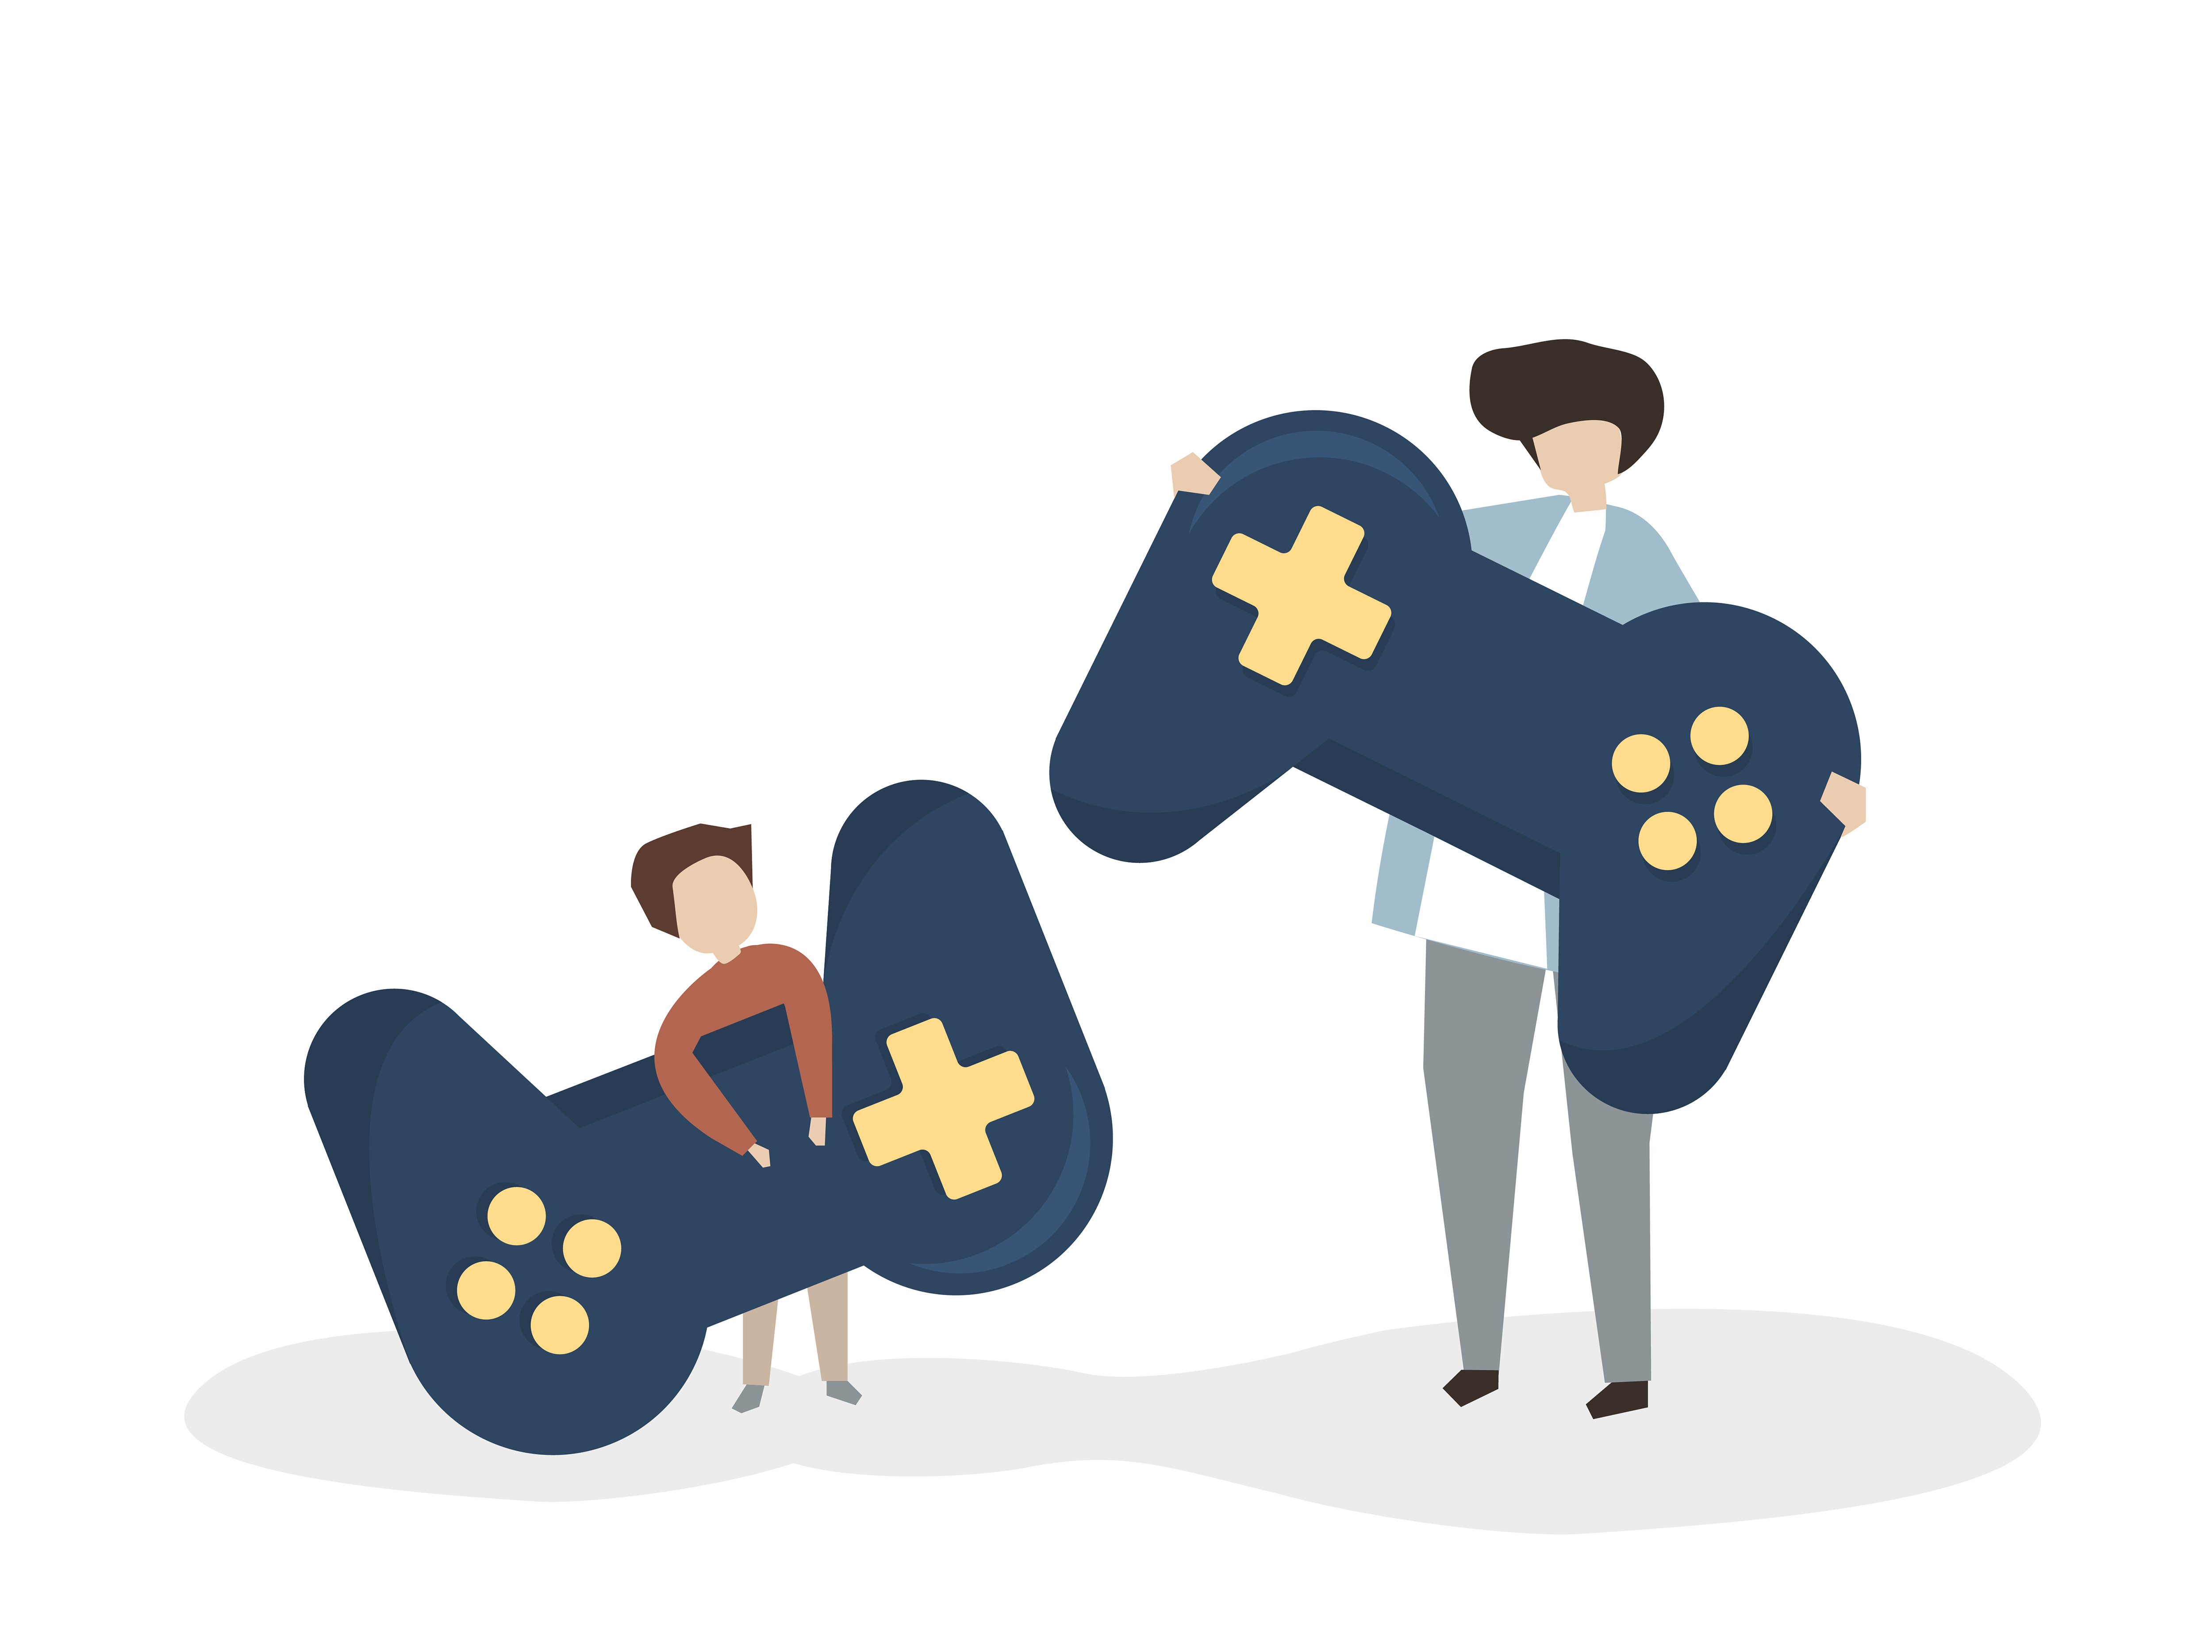

In [1]:
from IPython.display import Image
Image(filename = "/kaggle/input/datasets/salmamorsi/myimage/37168.jpg")

# introduction 


The video game industry has become one of the largest and fastest-growing sectors of the global entertainment market. According to a recent study by Research and Markets, the industry is projected to generate **$293.2 billion in revenue by 2027**, representing approximately **245% growth over the past decade**. The COVID-19 pandemic further accelerated this growth, with the industry expanding at an annual rate of around **14.5%** as gaming became one of the most popular forms of entertainment worldwide.

Contrary to the common perception that video games are primarily for children, modern gaming attracts players of all ages and demographics. The industry has also reached a point where the development of many major titles requires production budgets that rival or even exceed those of Hollywood movies.

Despite its enormous economic and cultural impact, the video game industry has received relatively limited attention in academic research. This project aims to explore video game data through data analysis techniques, identifying trends in sales, genres, critical reception, and other key factors that contribute to the success of video games.


## importing the libraries

In [2]:

import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from viz_utils import *
import plotly.express as px
import plotly.graph_objects as go

#from custom_transformers import *
#from ml_utils import *
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings
from sklearn.experimental import enable_iterative_imputer  # Explicitly enable it
from sklearn.impute import IterativeImputer

from sklearn.ensemble import IsolationForest

/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/publisher_summary.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/yearly_trends.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/genre_summary.csv
/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/platform_summary.csv
/kaggle/input/datasets/salmamorsi/myimage/37168.jpg


#  Data Ingestion and Inspection 

In [3]:
df = pd.read_csv("/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv")
pd.set_option('display.max_columns', None)

df.head()

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,M,69,6.7,34,1172,10.01,8.35,2.58,3.46,24.40,575.88,49.99,1,1,1,0,0,0,0,0,0,31.8,86.1
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,M,78,9.4,5,186,52.28,33.72,5.32,12.30,103.62,5056.51,59.99,1,0,1,1,0,0,0,0,0,13.1,55.4
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,T,76,6.6,33,363,2.90,1.48,0.75,0.91,6.04,138.60,59.99,0,0,0,0,0,0,0,0,0,9.8,20.9
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,USA,AA,M,62,7.0,28,532,6.76,3.27,0.73,2.34,13.10,36.98,0.00,0,1,1,1,0,0,0,0,0,9.1,44.8
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,AO,62,5.6,58,1280,25.12,15.94,7.02,7.71,55.79,2148.24,69.99,1,1,0,1,0,0,0,0,0,150.8,322.3


In [4]:
df.dtypes

game_id                                object
title                                  object
platform                               object
platform_type                          object
platform_maker                         object
platform_generation                     int64
genre                                  object
year                                    int64
publisher                              object
developer                              object
publisher_region                       object
publisher_tier                         object
esrb_rating                            object
metacritic_score                        int64
user_score                            float64
critic_review_count                     int64
user_review_count                       int64
na_sales_million                      float64
eu_sales_million                      float64
jp_sales_million                      float64
other_sales_million                   float64
global_sales_million              

In [5]:
df.shape

(50000, 35)

In [6]:
df.isnull().sum()

game_id                               0
title                                 0
platform                              0
platform_type                         0
platform_maker                        0
platform_generation                   0
genre                                 0
year                                  0
publisher                             0
developer                             0
publisher_region                      0
publisher_tier                        0
esrb_rating                           0
metacritic_score                      0
user_score                            0
critic_review_count                   0
user_review_count                     0
na_sales_million                      0
eu_sales_million                      0
jp_sales_million                      0
other_sales_million                   0
global_sales_million                  0
estimated_revenue_million_usd         0
launch_price_usd                      0
is_sequel                             0


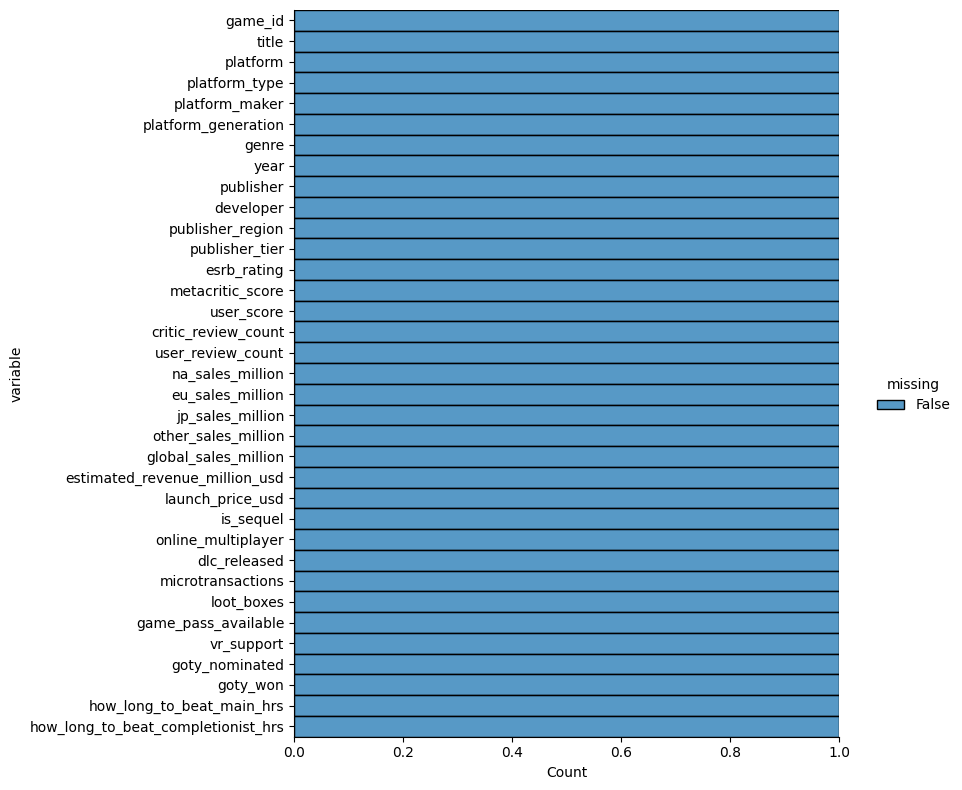

In [7]:
sns.displot(
    data=df.isnull().melt(value_name='missing'),
    y='variable',
    hue='missing',
    multiple='fill',
    height=8,
    aspect=1.1
)



we have no missing values in our data

# Exploratory Data Analysis



## Filtering High-Rated Next-Generation Games

To focus the analysis on modern, critically acclaimed games, the dataset was filtered using three conditions:

> **Release Year ≥ 2020:** Includes only games released during the current console generation.
>
> 
> **Platform:** Selects gamesavailable on either the PlayStation 5 or Xbox Series X.
>
> 
> **Metacritic Score ≥ 85:** Keeps only titles that received strong critical reviews.

In [8]:
df2 = df[(df["year"] >= 2020) & (df["platform"].isin(["PlayStation 5", "Xbox Series X"])) 
& (df["metacritic_score"] >= 85)]

In [9]:
df2.shape

(137, 35)

### Which genres dominate among highly rated games?

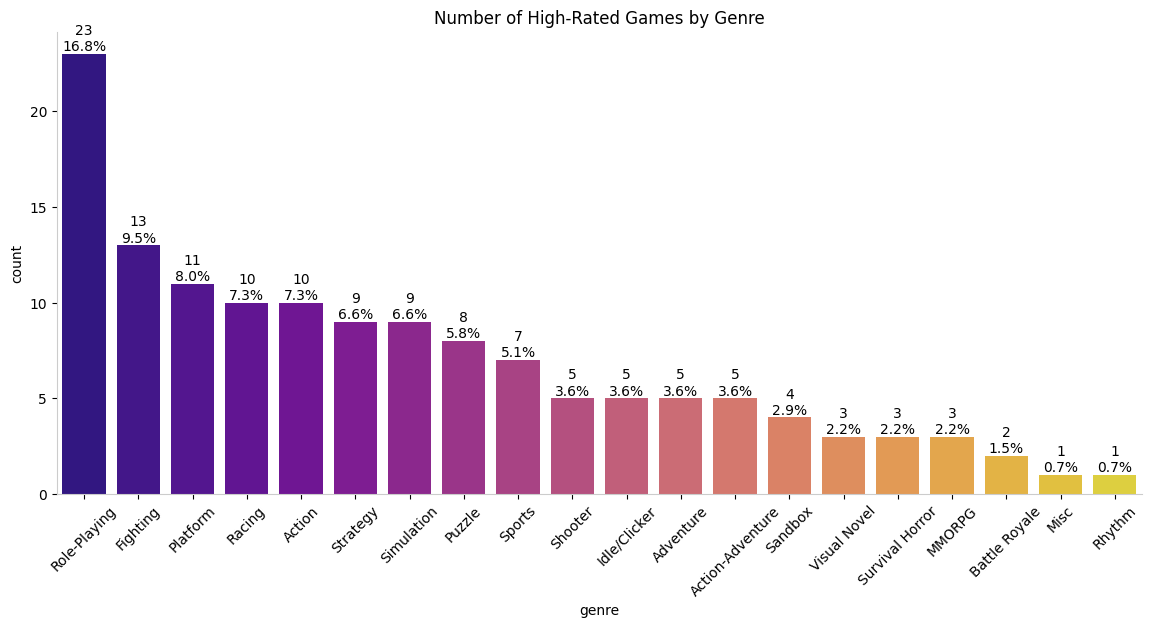

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

single_countplot(df2, x='genre', ax=ax)
plt.title("Number of High-Rated Games by Genre")

plt.xticks(rotation=45)

plt.show()

In [11]:
df2["platform"].value_counts()

platform
PlayStation 5    137
Name: count, dtype: int64

*we have no xbox highly rated games to compare*

### Do games that critics love also receive high user ratings? 

In [12]:
df2[["metacritic_score","user_score"]].corr().style.background_gradient()

,metacritic_score,user_score
metacritic_score,1.000000,0.395730
user_score,0.395730,1.000000


In [13]:
top_sales = df2.sort_values(
    "global_sales_million",
    ascending=False
).head(10)
top_sales

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,esrb_rating,metacritic_score,user_score,critic_review_count,user_review_count,na_sales_million,eu_sales_million,jp_sales_million,other_sales_million,global_sales_million,estimated_revenue_million_usd,launch_price_usd,is_sequel,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
11446,G011447,The Witcher 4: Eternal,PlayStation 5,Console,Sony,9,Role-Playing,2025,2K Games,2K Games,USA,AAA,M,91,10.0,35,95,120.12,101.38,21.35,43.94,286.79,13456.53,79.99,0,0,1,0,0,0,0,1,0,80.8,286.1
18072,G018073,Warzone 2,PlayStation 5,Console,Sony,9,Battle Royale,2023,FromSoftware,FromSoftware,Japan,AAA,T,93,9.7,16,13,108.99,96.85,35.10,11.95,252.89,9156.79,49.99,1,1,1,1,1,0,0,0,0,120.1,342.3
3574,G003575,Elder Scrolls Online: Reckoning,PlayStation 5,Console,Sony,9,MMORPG,2020,Bandai Namco,InXile Entertainment,Japan,AAA,Not Rated,91,7.9,35,454,109.82,63.26,24.19,37.96,235.23,9845.68,59.99,0,1,0,1,1,0,0,1,0,193.2,694.5
41588,G041589,Halo : Redux,PlayStation 5,Console,Sony,9,Action,2026,Electronic Arts,Electronic Arts,USA,AAA,M,90,7.7,15,144,92.40,54.19,6.36,33.25,186.20,9135.22,49.99,0,1,1,0,0,1,0,0,0,7.6,15.7
42483,G042484,Forza Motorsport 6,PlayStation 5,Console,Sony,9,Racing,2020,Sony Interactive,Rockstar Games,Japan,AAA,T,85,8.2,24,576,89.46,46.44,13.51,19.90,169.31,7262.81,49.99,1,0,1,0,0,0,0,1,1,14.6,39.6
1839,G001840,Age of Empires VIII,PlayStation 5,Console,Sony,9,Strategy,2020,Nintendo,Nintendo,Japan,AAA,Not Rated,94,9.0,28,45,58.81,47.45,37.83,23.13,167.22,7327.72,39.99,1,0,1,1,0,0,0,0,0,48.7,239.1
44101,G044102,Forza Motorsport 3,PlayStation 5,Console,Sony,9,Racing,2025,Bandai Namco,Bandai Namco,Japan,AAA,E10+,86,9.0,26,40,61.65,46.35,31.58,23.48,163.06,7509.14,59.99,1,0,0,1,1,1,0,1,0,18.2,56.8
22970,G022971,MLB The Show 2025,PlayStation 5,Console,Sony,9,Sports,2025,Sega,Electronic Arts,Japan,AAA,M,87,9.0,10,359,64.31,40.02,25.45,23.43,153.21,7603.95,69.99,1,1,1,1,0,0,0,0,0,17.9,70.3
24823,G024824,Lost Knight,PlayStation 5,Console,Sony,9,Action,2022,CD Projekt,CD Projekt,Poland,AAA,E10+,91,9.2,22,553,76.53,39.93,7.71,26.96,151.13,5059.32,59.99,0,0,1,0,0,1,0,1,0,15.4,72.4
35504,G035505,Valheim Reborn,PlayStation 5,Console,Sony,9,Sandbox,2021,Rockstar Games,Rockstar Games,USA,AAA,E10+,87,8.9,48,116,58.29,49.11,7.60,21.51,136.51,6263.26,39.99,0,1,1,1,0,1,0,1,0,143.5,432.2


## Summary Statistics 

### What is the distribution of game sales and launch prices?

In [14]:
summary = (
    df[["global_sales_million", "launch_price_usd"]]
    .agg(["min", "max", "mean", "sum"])
)

summary["global_sales_million"] = summary["global_sales_million"].map(lambda x: f"{x:,.2f}")
summary["launch_price_usd"] = summary["launch_price_usd"].map(lambda x: f"${x:,.2f}")
summary

,global_sales_million,launch_price_usd
min,0.05,$0.00
max,"1,494.68",$79.99
mean,26.03,$42.03
sum,"1,301,736.91","$2,101,442.68"


In [15]:

df_2020 = df[df["year"] >= 2020].copy()

genres = sorted(df_2020["genre"].dropna().unique())

colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756",
    "#72B7B2", "#EECA3B", "#B279A2", "#FF9DA6",
    "#9D755D", "#BAB0AC"
]

fig = go.Figure()

for i, genre in enumerate(genres):

    genre_data = df_2020[df_2020["genre"] == genre]

    fig.add_trace(
        go.Box(
            y=genre_data["global_sales_million"],
            name=genre,

            # Box settings
            boxpoints="all",
            boxmean=True,
            notched=True,
            jitter=0.45,
            pointpos=-1.6,
            whiskerwidth=0.7,

            # Marker styling
            marker=dict(
                size=5,
                color=colors[i % len(colors)],
                opacity=0.6
            ),

            fillcolor=colors[i % len(colors)],
            line=dict(color="black", width=1),

            # Hover information
            text=genre_data["title"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Genre: %{x}<br>"
                "Global Sales: %{y:.2f} Million"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Global Sales Distribution by Genre (Games Released Since 2020)",
    xaxis_title="Genre",
    yaxis_title="Global Sales (Millions)",
    template="plotly_white",
    height=650,
    showlegend=False,
    hovermode="closest"
)

fig.show()

### Which genres are the most commercially successful?

In [16]:
result = df.groupby("genre").agg(
    average_metacritic=("metacritic_score", "mean"),
    total_global_sales=("global_sales_million", "sum")
).sort_values(by="total_global_sales", ascending=False)
result.style.background_gradient()

,average_metacritic,total_global_sales
genre,,
Sports,71.239275,263838.830000
Action,73.497599,208197.930000
Shooter,74.042607,169891.120000
Role-Playing,77.459808,108963.880000
Platform,74.005024,85004.800000
Racing,74.399585,82745.330000
Fighting,74.942050,62525.890000
Simulation,74.436442,53977.480000
Adventure,76.588652,39900.590000


###  How many games have microtransactions  ???

In [17]:
# Shortcut to get percentages directly
df['microtransactions'].value_counts(normalize=True) * 100

microtransactions
0    68.902
1    31.098
Name: proportion, dtype: float64

In [18]:
features = [
    "dlc_released",
    "microtransactions",
    "loot_boxes",
    "game_pass_available"
]



In [19]:
percentage_table = (
    (df[features].mean() * 100)
    .round(2)
    .rename("Percentage")
    .to_frame()
)

percentage_table["Percentage"] = (
    percentage_table["Percentage"].astype(str) + "%"
)

percentage_table

,Percentage
dlc_released,62.31%
microtransactions,31.1%
loot_boxes,6.5%
game_pass_available,3.65%


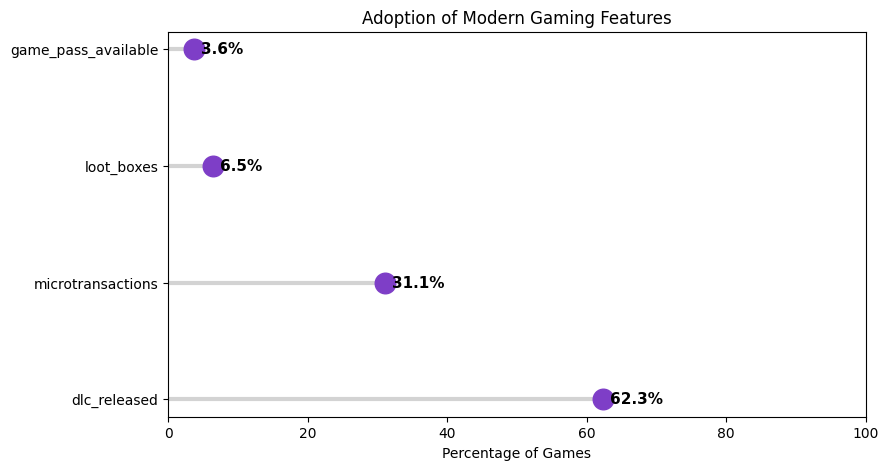

In [20]:

percentages = (df[features].mean() * 100).round(2)

fig, ax = plt.subplots(figsize=(9,5))

ax.hlines(
    y=percentages.index,
    xmin=0,
    xmax=percentages.values,
    color="lightgray",
    linewidth=3
)

ax.scatter(
    percentages.values,
    percentages.index,
    s=220,
    color="#7E3EC7",
    zorder=3
)

for i, value in enumerate(percentages.values):
    ax.text(value + 1,
            i,
            f"{value:.1f}%",
            va="center",
            fontsize=11,
            fontweight="bold")

ax.set_xlim(0,100)
ax.set_xlabel("Percentage of Games")
ax.set_title("Adoption of Modern Gaming Features")

plt.show()

# Feature Engineering

### Which game relied most heavily on North American sales?

In [21]:
# 1. Group by game title and sum up the raw sales figures first
grouped_games = df.groupby('title')[['na_sales_million', 'global_sales_million']].sum()

# 2. Calculate the true share on the total combined sales
grouped_games['Total_NA_Share'] = grouped_games['na_sales_million'] / grouped_games['global_sales_million']

# 3. Sort by the true share and grab the top game
top_game_NA = grouped_games.sort_values(
    by="Total_NA_Share",
    ascending=False
)
# Get the name of the #1 game
print(top_game_NA.index[0])

The Elder Scrolls IX: The Fallen


In [22]:
Image(url="https://tse2.mm.bing.net/th/id/OIP.cWSewXRyTKEzis9AVo-sfAHaEK?rs=1&pid=ImgDetMain&o=7&rm=3")

### top $10$ publishers based on total Global sales and number of games

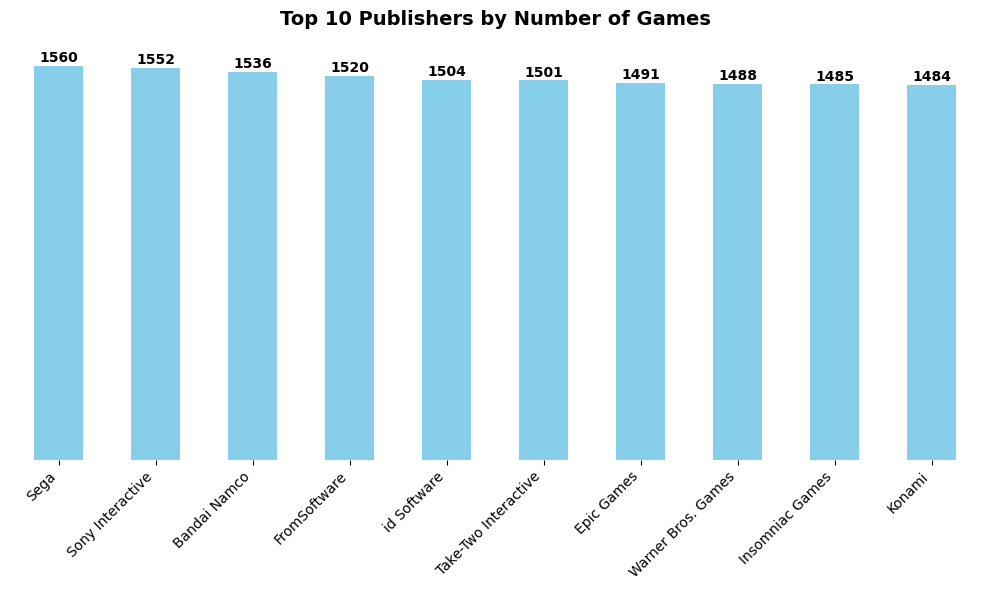

In [23]:
plt.figure(figsize=(10, 6))

top_10_publishers = df['publisher'].value_counts().head(10)
top_10_publishers.plot(kind='bar', color='skyblue')


for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)

plt.gca().get_yaxis().set_visible(False)



for i, v in enumerate(top_10_publishers):
    plt.text(
        x=i,           # The horizontal position on the chart
        y=v + 2,       # The vertical position (slightly above the top of the bar)
        s=str(int(v)), # The text label to display (converted to integer)
        ha='center',   # Center the text horizontally over the bar
        va='bottom',   # Align the bottom of the text string to the coordinate
        fontsize=10,
        fontweight='bold',
        color='black'
    )
plt.title('Top 10 Publishers by Number of Games', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Games', fontsize=12, labelpad=10)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

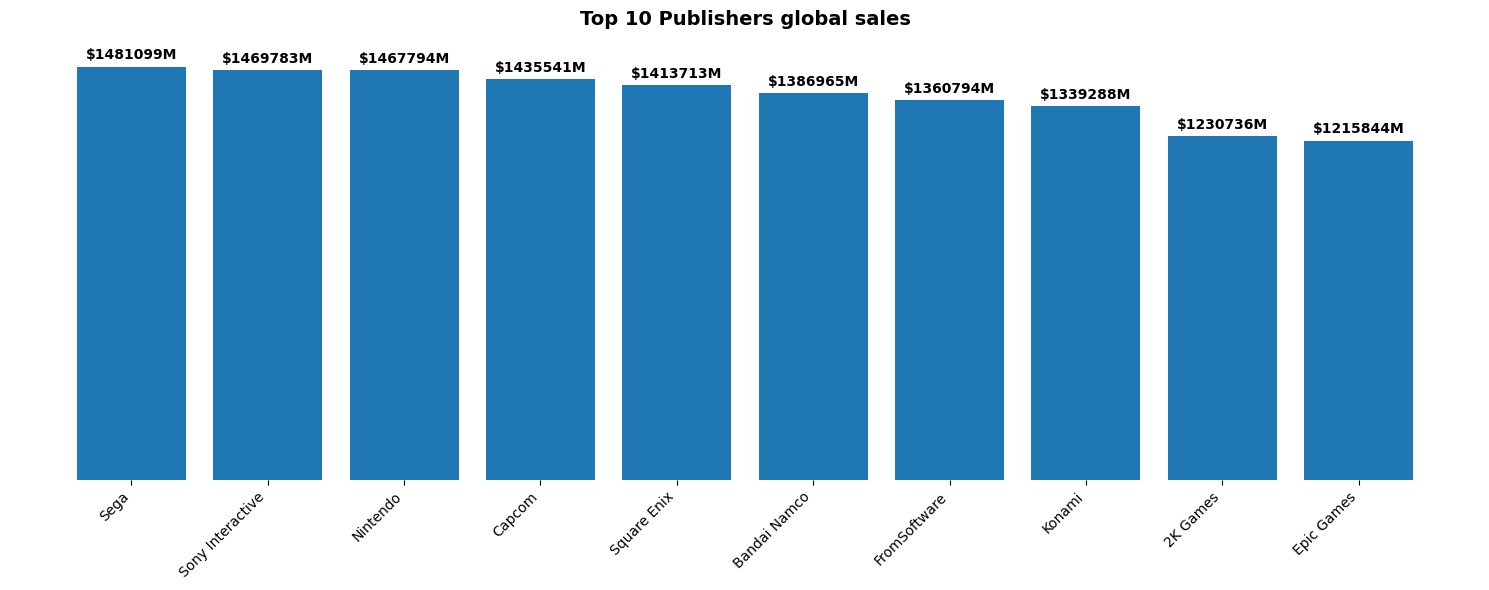

In [24]:
plt.figure(figsize=(15, 6))

top_10_sales = df.groupby('publisher')['estimated_revenue_million_usd'].sum().sort_values(ascending=False).head(10)

plt.bar(x =top_10_sales.index , height = top_10_sales.values)


for spine in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[spine].set_visible(False)


plt.gca().get_yaxis().set_visible(False)


for i, v in enumerate(top_10_sales):
    plt.text(
        x=i,           
        y=v + (top_10_sales.max() * 0.01), # Dynamic padding: adds 1% of max value above the bar
        s=f"${int(v)}M",                   # Formats it nicely as currency (e.g., $150M)
        ha='center',   
        va='bottom',   
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.title('Top 10 Publishers global sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



### Kernel Density Estimate (KDE) 

**The KDE plot illustrates the distribution of Metacritic scores across all games in the dataset. The dashed red line represents the mean Metacritic score, providing a reference for the overall level of critical reception. The shape of the density curve indicates where review scores are most concentrated and whether the distribution is skewed toward higher or lower ratings. This visualization helps determine whether most games receive average reviews or whether critically acclaimed and poorly reviewed titles are more common.**

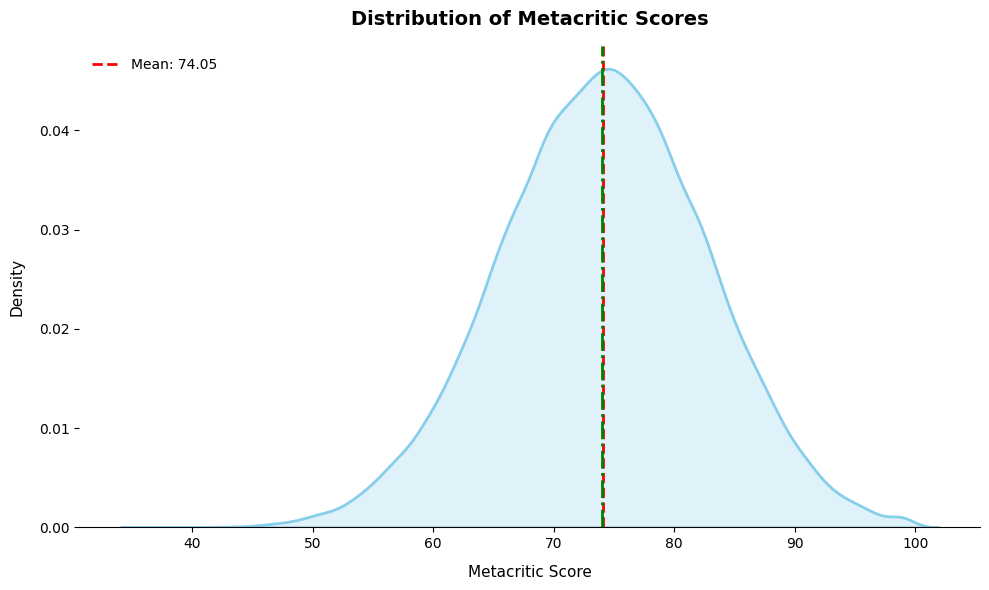

In [25]:
plt.figure(figsize=(10, 6))

# 1. Plot the distribution curve
sns.kdeplot(data=df, x="metacritic_score", fill=True, color="skyblue", linewidth=2)

# 2. Calculate the mean safely using pandas (ignores missing values)
mean_val = df["metacritic_score"].mean()

# 3. Add the vertical mean line
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')

# 4. Clean up the borders to match your design style
for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)

# Clean up typography and spacing
plt.title('Distribution of Metacritic Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Metacritic Score', fontsize=11, labelpad=10)
plt.ylabel('Density', fontsize=11, labelpad=10)
plt.legend(frameon=False, loc='upper left') # Removes the box outline around the legend
median_val = df["metacritic_score"].median()

plt.axvline(
    median_val,
    color="green",
    linestyle="-.",
    linewidth=2,
    label=f"Median = {median_val:.2f}"
)

plt.tight_layout()
plt.show()

###  Relationship and Correlation Analysis (pandas + seaborn)


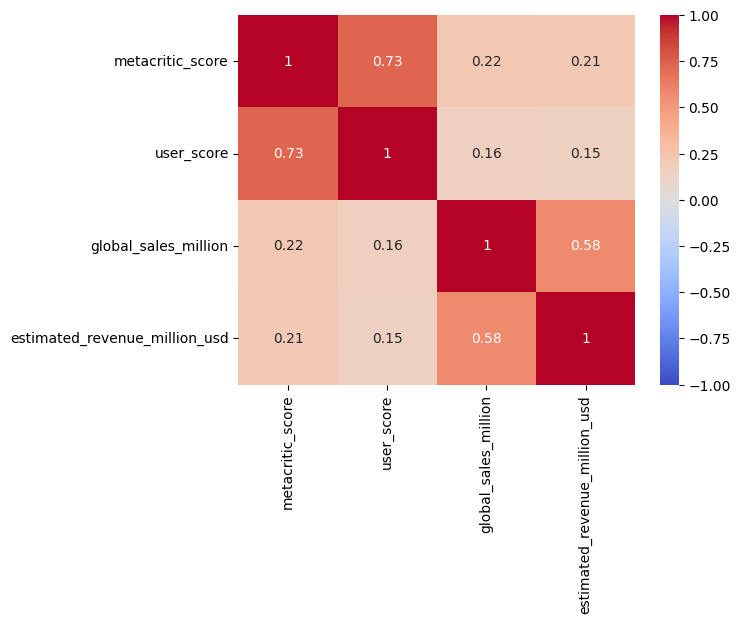

In [26]:
selected_columns = df[["metacritic_score","user_score","global_sales_million","estimated_revenue_million_usd"]]

matrix = selected_columns.corr()

sns.heatmap(matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

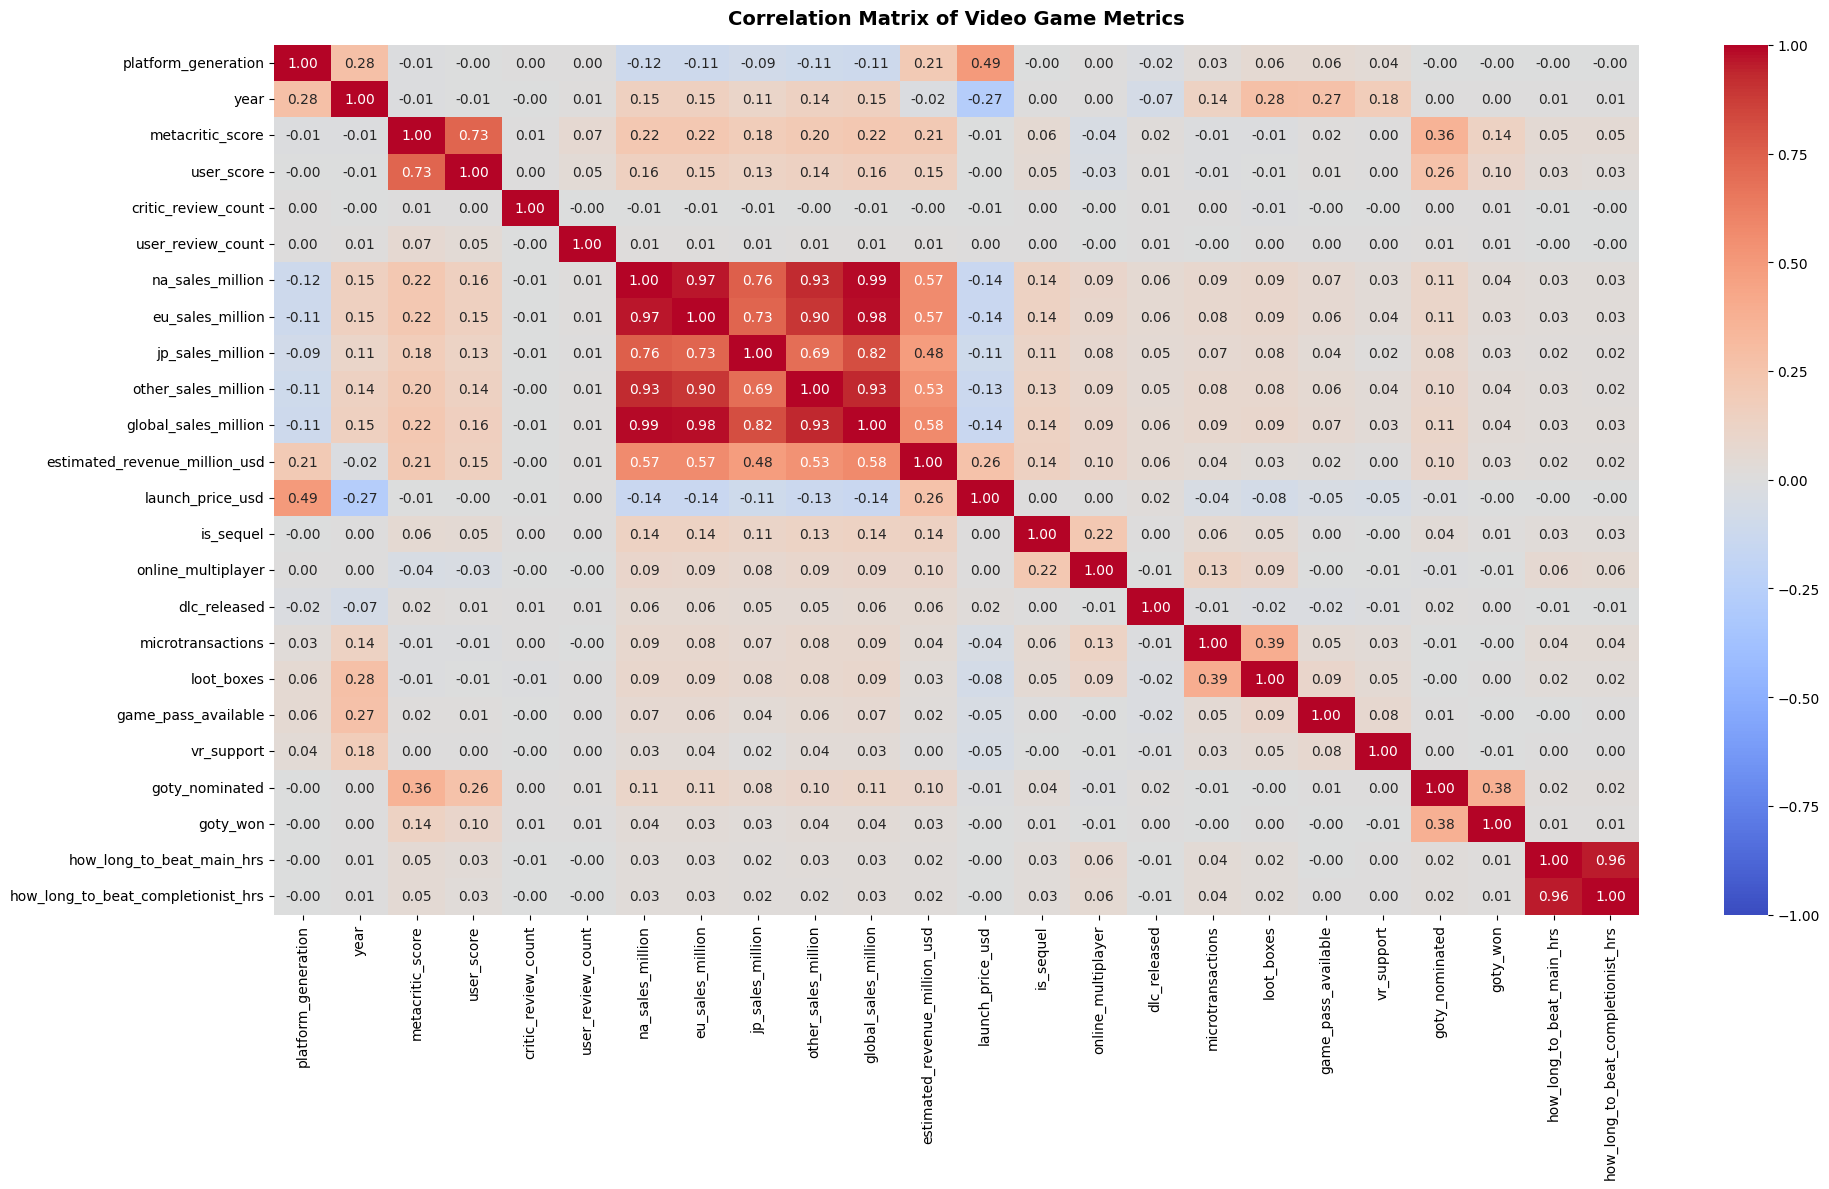

In [27]:
# Create the correlation matrix safely by filtering for numbers only
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plot your exact heatmap code
plt.figure(figsize=(20, 12)) # Added a bit of extra space for readability
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix of Video Game Metrics', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


## Some games are massive hits across multiple consoles, while others are platform exclusives.

### Which games were released on the largest number of platforms?



In [28]:
top_5games =df.groupby('title')['platform'].nunique().sort_values(ascending=False).head(5)
top_5games

title
MLB The Show 2026    33
Madden NFL 2024      33
UFC 3                33
Overwatch 5          33
UFC 4                33
Name: platform, dtype: int64

## the disagreement between critics and players

In [29]:
df["score_diff"]= abs(df["metacritic_score"] -df["user_score"]*10)

In [30]:
biggest3differences = df.sort_values(by="score_diff", ascending=False).head(3)

In [31]:
print(biggest3differences[["title", "metacritic_score", "user_score", "score_diff"]])

                    title  metacritic_score  user_score  score_diff
26405     Valorant Legacy                87         5.7        30.0
32292         Titanfall 6                83         5.3        30.0
13903  Super Mario Legend                71         4.2        29.0


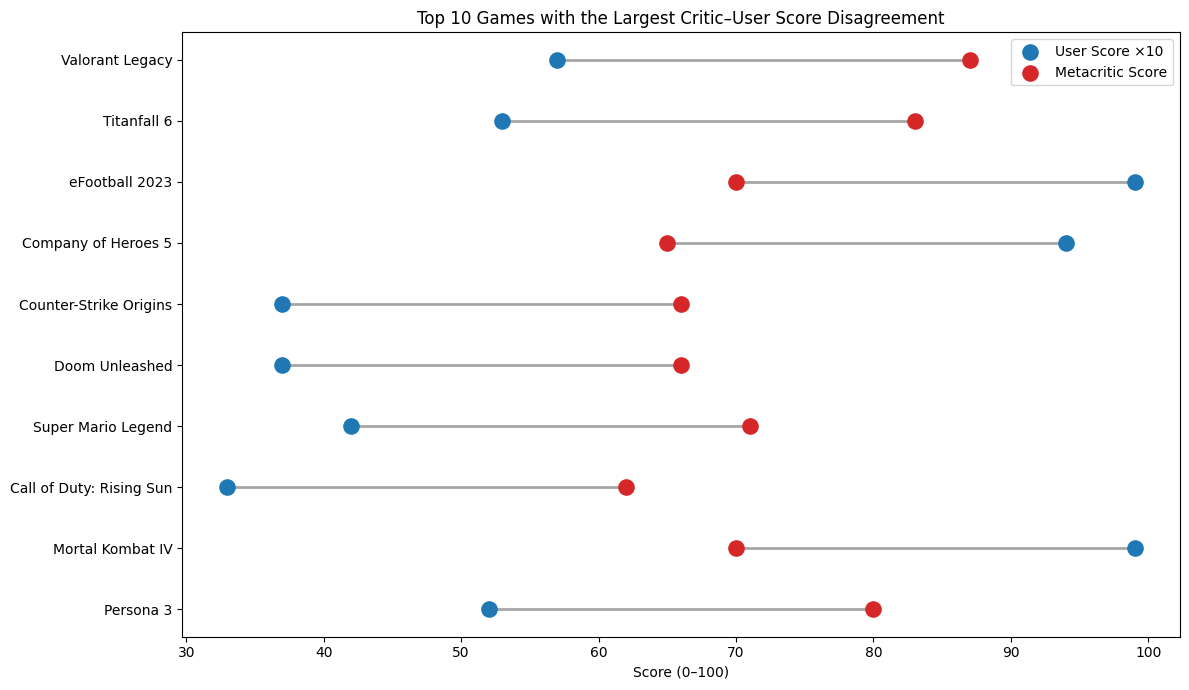

In [32]:

top10 = (
    df.sort_values("score_diff", ascending=False)
      .head(10)
      .sort_values("score_diff")
)

fig, ax = plt.subplots(figsize=(12, 7))

# Connecting lines
for i in range(len(top10)):
    ax.plot(
        [top10["user_score"].iloc[i] * 10,
         top10["metacritic_score"].iloc[i]],
        [i, i],
        color="gray",
        linewidth=2,
        alpha=0.7
    )

# User scores
ax.scatter(
    top10["user_score"] * 10,
    range(len(top10)),
    s=120,
    color="#1f77b4",
    label="User Score ×10",
    zorder=3
)

# Critic scores
ax.scatter(
    top10["metacritic_score"],
    range(len(top10)),
    s=120,
    color="#d62728",
    label="Metacritic Score",
    zorder=3
)

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10["title"])

ax.set_xlabel("Score (0–100)")
ax.set_title("Top 10 Games with the Largest Critic–User Score Disagreement")

ax.legend()

plt.tight_layout()
plt.show()

###  Segmenting by Release Era
* Let's see how game characteristics changed over time.



In [33]:
gaming_eras = {
    "The 8-Bit & 16-Bit Era " :1995,     #1985-1995
    "The 3D Era" :2005,             #1996-2005
    "The Online & HD Era ":2014,   #2006-2014
    "The Modern & UH3D Era":2026   #2015- present
}

In [34]:
df["era"] = pd.cut(df["year"], bins =[1985] +list(gaming_eras.values()) , labels = list(gaming_eras.keys()))

###  Which genres dominated each era?

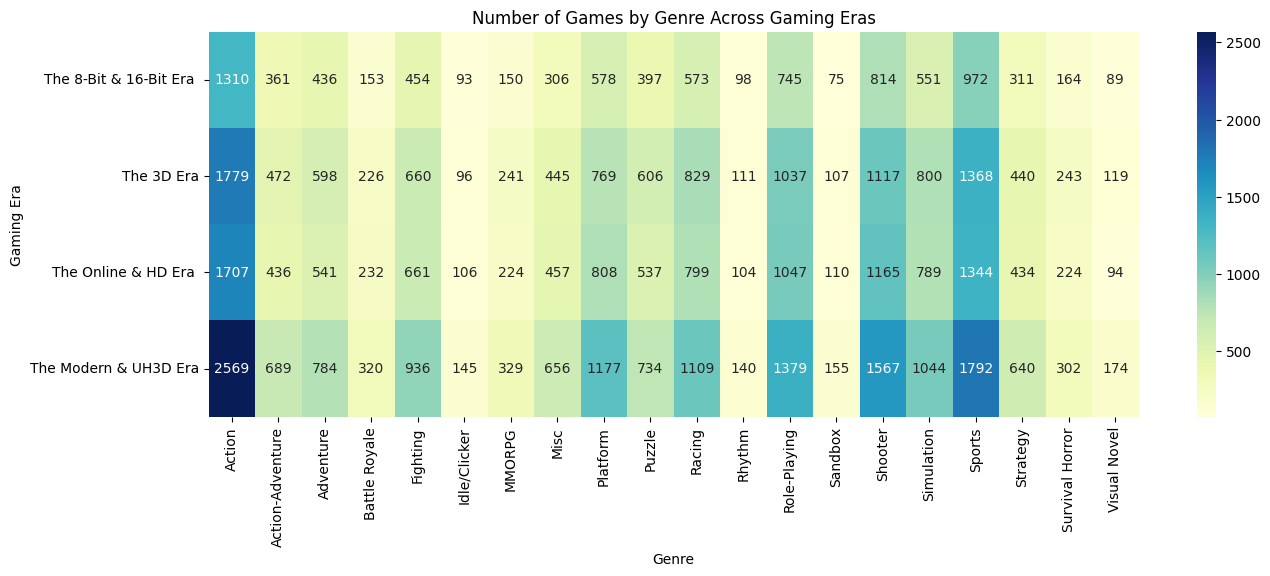

In [35]:
genre_era = pd.crosstab(df["era"], df["genre"])

plt.figure(figsize=(15,5))

sns.heatmap(
    genre_era,
    annot=True,
    cmap="YlGnBu",
    fmt="d"
)

plt.title("Number of Games by Genre Across Gaming Eras")
plt.xlabel("Genre")
plt.ylabel("Gaming Era")

plt.show()

In [36]:
flow = (
    df.groupby(["era", "genre"])
      .size()
      .reset_index(name="count")
)


eras = flow["era"].unique().tolist()
genres = flow["genre"].unique().tolist()

nodes = eras + genres

node_indices = {node: i for i, node in enumerate(nodes)}


source = flow["era"].map(node_indices)
target = flow["genre"].map(node_indices)
value = flow["count"]


fig = go.Figure(go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
))

fig.update_layout(
    title="Flow of Game Genres Across Gaming Eras",
    font_size=12,
    height=650
)

fig.show()

## We want to look at niche publishers vs. industry titans.



In [37]:
result = df.groupby('publisher').filter(lambda x: len(x) > 50)
print(result['publisher'].unique())

['CD Projekt' 'Ubisoft' 'Microsoft Studios' 'InXile Entertainment'
 'Naughty Dog' '2K Games' 'Activision Blizzard' 'Sega' 'Humble Games'
 'Square Enix' 'Bethesda Softworks' 'Team17' 'Rockstar Games'
 'Devolver Digital' 'Nintendo' 'Take-Two Interactive'
 'Remedy Entertainment' 'Epic Games' 'Warner Bros. Games'
 'Supergiant Games' 'Valve' 'Deep Silver' 'Konami' 'id Software'
 'FromSoftware' 'ConcernedApe' '505 Games' 'Capcom' 'Sony Interactive'
 'Ghost Ship Games' 'Larian Studios' 'Toby Fox' 'Insomniac Games'
 'Bandai Namco' 'Electronic Arts' 'Chucklefish' 'Other' 'Double Fine'
 'tinyBuild' 'Annapurna Interactive' 'Klei Entertainment' 'Bungie'
 'THQ Nordic' 'Unknown Worlds' 'Focus Entertainment' 'Coffee Stain'
 'Obsidian Entertainment' 'Paradox Interactive' 'Motion Twin' 'Raw Fury'
 'Nomada Studio']


 * To identify publishers that consistently produce high-quality games, publishers with fewer than 10 games were excluded from the analysis. This prevents small sample sizes from skewing the results. The remaining publishers were ranked by their median Metacritic score, providing a more robust measure of typical game quality than the mean, which can be heavily influenced by extreme values. 

In [38]:
publishers_info = df.groupby("publisher").agg(
    game_count=("title", "count"),
    median_score=("metacritic_score", "median")
).round(0)
filtered_publishers = publishers_info[publishers_info["game_count"] >= 10]

filtered_publishers.sort_values(by="median_score", ascending=False).head(10).style.background_gradient()

,game_count,median_score
publisher,,
2K Games,1467,76.000000
Activision Blizzard,1435,76.000000
Bandai Namco,1536,76.000000
Capcom,1456,76.000000
Bethesda Softworks,1467,76.000000
Bungie,1439,76.000000
CD Projekt,1417,76.000000
Electronic Arts,1478,76.000000
Epic Games,1491,76.000000


### The Sales Outlier 

> Are global sales driven by a few massive hits, or do most games perform similarly?

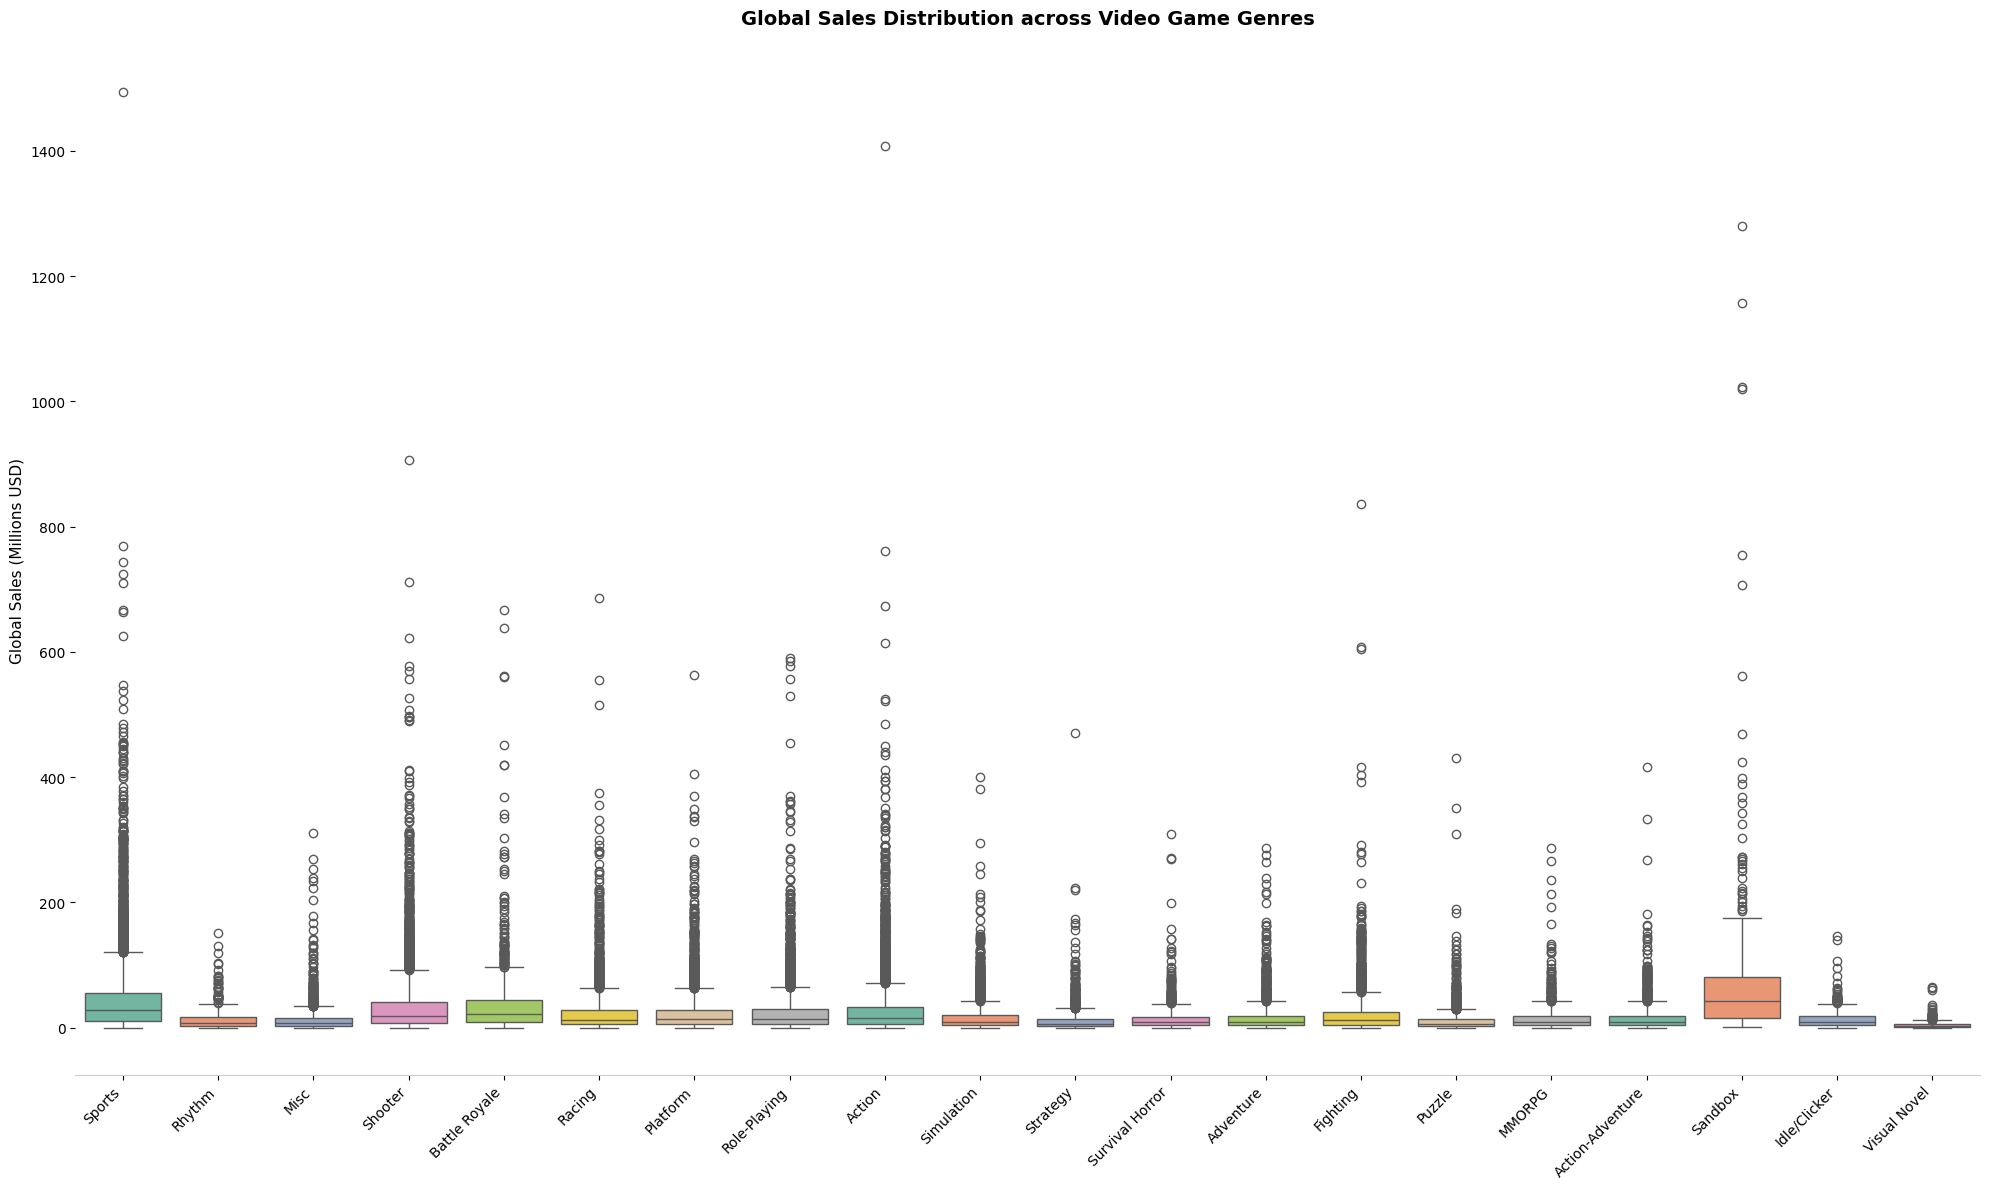

In [39]:
plt.figure(figsize=(20, 12))

# Use seaborn to split global sales by genre effortlessly
ax = sns.boxplot(
    data=df, 
    x="genre", 
    y="global_sales_million", 
    palette="Set2"  # Gives each genre a unique color palette
)

# Clean up the chart borders
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Keep the bottom spine but make it a subtle color
ax.spines['bottom'].set_color('#cccccc')

# Turn off the y-axis grid lines (Challenge Goal)
ax.yaxis.grid(False) 
ax.xaxis.grid(False)

# Styling typography
plt.title('Global Sales Distribution across Video Game Genres', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('') # Drop the redundant 'genre' label
plt.ylabel('Global Sales (Millions USD)', fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**This analysis compares the average completionist playtime and average estimated revenue across different game genres. It explores whether genres requiring longer playtimes are also associated with higher commercial performance. Genres positioned in the upper-right corner of the chart combine lengthy gameplay with strong revenue, while those in the lower-right indicate long experiences that do not necessarily translate into higher earnings. This comparison helps reveal whether player engagement, measured through completion time, is associated with financial success.**

In [40]:
hours_per_value = (
    df.groupby("genre")
      .agg(
          average_revenue=("estimated_revenue_million_usd", "mean"),
          average_completion_hours=("how_long_to_beat_completionist_hrs", "mean")
      )
)

In [41]:
hours_per_value

,average_revenue,average_completion_hours
genre,,
Action,667.439964,41.683391
Action-Adventure,397.806096,42.376272
Adventure,417.545215,41.403421
Battle Royale,885.098556,354.226133
Fighting,550.408305,20.795799
Idle/Clicker,390.198467,41.940000
MMORPG,440.954338,689.898957
Misc,327.793296,42.628376
Platform,615.937878,35.182861


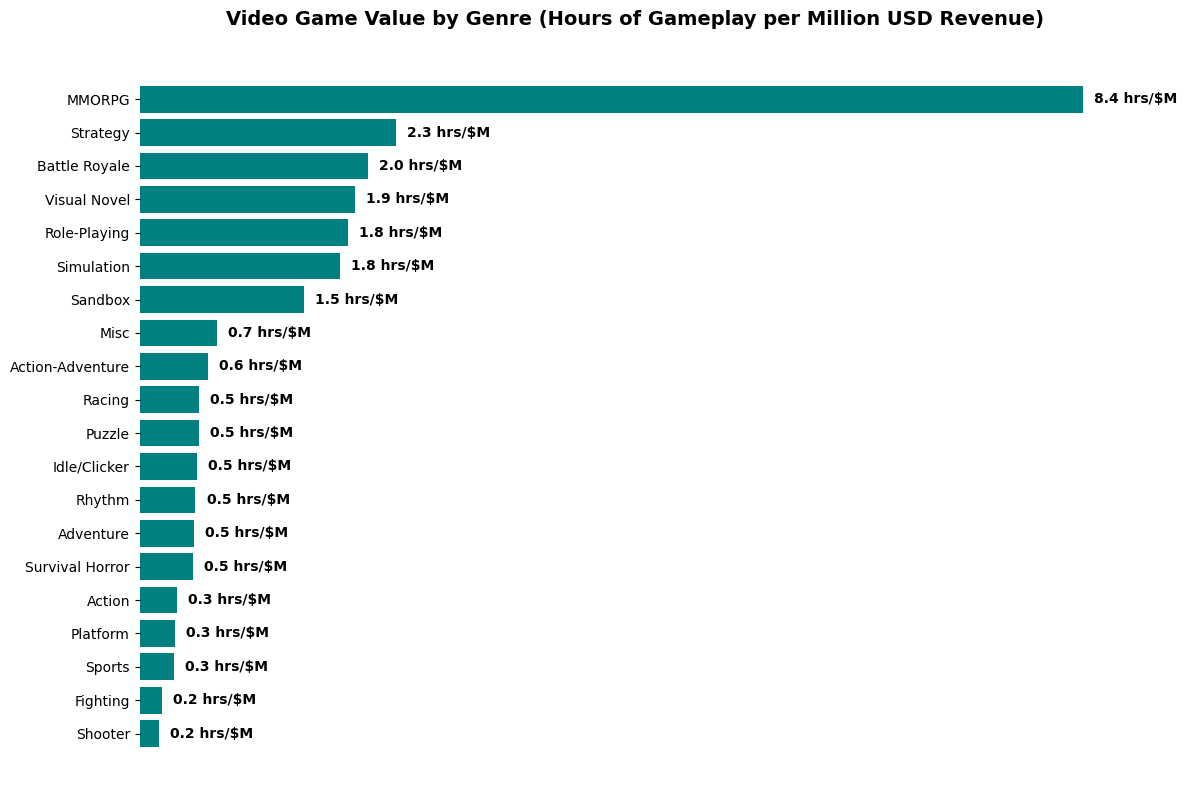

In [42]:

# 1. Calculate row-level efficiency
df["hours_per_revenue"] = df["how_long_to_beat_completionist_hrs"] / df["estimated_revenue_million_usd"]

# 2. CRITICAL FIX: Keep only rows with valid, finite numbers (removes NaN and Inf)
df_clean = df[np.isfinite(df["hours_per_revenue"])]

# 3. Group by genre using the cleaned data
genre_efficiency = df_clean.groupby("genre")["hours_per_revenue"].mean().sort_values(ascending=True)

# 4. Setup the horizontal chart
plt.figure(figsize=(12, 8))
ax = plt.gca()
bars = ax.barh(genre_efficiency.index, genre_efficiency.values, color='teal')

# 5. Clean styling
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.get_xaxis().set_visible(False) 

# 6. Add Annotations
for bar in bars:
    width = bar.get_width()
    ax.annotate(
        text=f"{width:.1f} hrs/$M",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(8, 0),                  
        textcoords="offset points",
        va='center',                    
        ha='left',                      
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.title('Video Game Value by Genre (Hours of Gameplay per Million USD Revenue)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

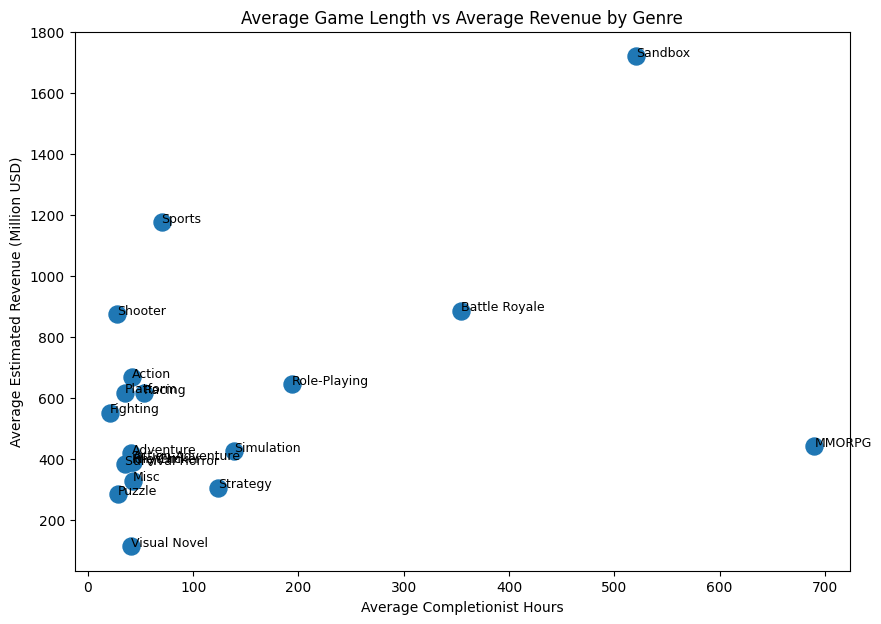

In [43]:
plt.figure(figsize=(10,7))

plt.scatter(
    hours_per_value["average_completion_hours"],
    hours_per_value["average_revenue"],
    s=150
)

for genre in hours_per_value.index:
    plt.annotate(
        genre,
        (
            hours_per_value.loc[genre, "average_completion_hours"],
            hours_per_value.loc[genre, "average_revenue"]
        ),
        fontsize=9
    )

plt.xlabel("Average Completionist Hours")
plt.ylabel("Average Estimated Revenue (Million USD)")
plt.title("Average Game Length vs Average Revenue by Genre")

plt.show()

## Does a short, snappy game title sell better than a super long one?



In [44]:
df["title_length"] = df["title"].str.len()

df["title_length"].corr(df["global_sales_million"])

np.float64(-0.09287093667656113)

*as we can see here there is no correlation at all*

## How common are remasters, remakes, and special editions in the dataset?

In [45]:
words = ['edition', 'remaster', 'remake']

regex_pattern = '|'.join(words)

filtered_df = df[df['title'].str.contains(regex_pattern, case=False, na=False)]

In [46]:
percentage = (len(filtered_df) / len(df)) * 100

print(f"Percentage of updated releases: {percentage:.2f}%")

Percentage of updated releases: 1.83%


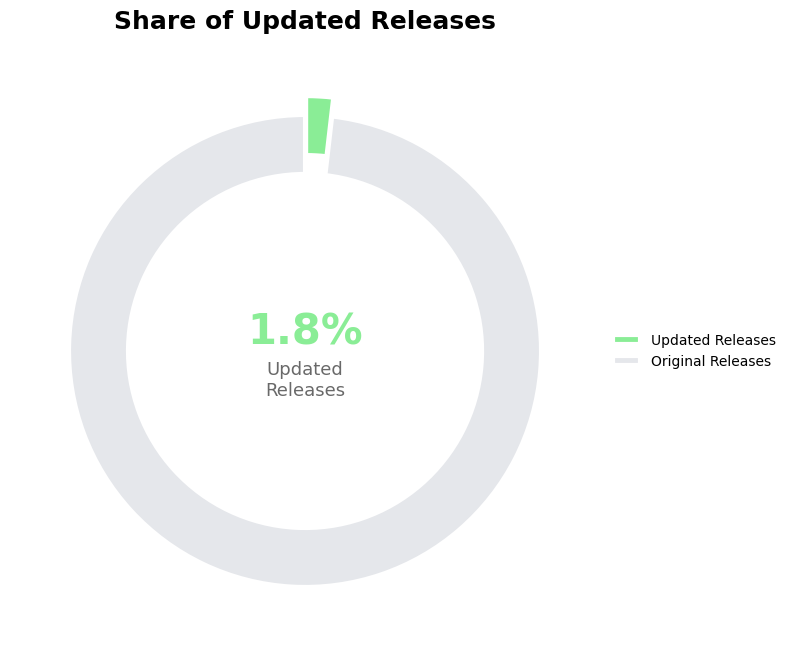

In [47]:

# Prepare data
words = ["edition", "remaster", "remake"]
pattern = r"(" + "|".join(words) + r")"

updated = df["title"].str.contains(pattern, case=False, na=False)

updated_count = updated.sum()
original_count = len(df) - updated_count

sizes = [updated_count, original_count]
colors = ["#8aed96", "#E5E7EB"]  

fig, ax = plt.subplots(figsize=(8,8))
explode = [0.08, 0]

wedges, texts = ax.pie(
    sizes,
    explode=explode,
    #shadow=True,

    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(
        width=0.25,
        edgecolor="white",
        linewidth=3
    )
)

percentage = updated_count / len(df) * 100

# Center text
ax.text(
    0,
    0.08,
    f"{percentage:.1f}%",
    ha="center",
    va="center",
    fontsize=30,
    fontweight="bold",
    color="#8aed96"
)

ax.text(
    0,
    -0.12,
    "Updated\nReleases",
    ha="center",
    va="center",
    fontsize=13,
    color="dimgray"
)

plt.title(
    "Share of Updated Releases",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.legend(
    wedges,
    ["Updated Releases", "Original Releases"],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False
)
plt.cm.Blues([0.4,0.8])
plt.tight_layout()
plt.show()

## Do publishers from different regions tend to produce games with different average global sales across genres?

In [48]:
pivot = df.pivot_table(index="genre", columns="publisher_region", values="global_sales_million", aggfunc="mean" , fill_value =0)
pivot.style.background_gradient(cmap='YlGnBu', axis=None).format("{:.2f}")

publisher_region,Austria,Belgium,Canada,Denmark,Finland,France,Germany,Italy,Japan,Poland,Spain,Sweden,UK,USA,Various
genre,,,,,,,,,,,,,,,
Action,7.94,8.25,3.78,4.10,8.61,20.15,9.10,9.37,38.85,35.61,4.74,6.36,5.98,29.42,5.10
Action-Adventure,4.29,5.91,1.89,2.18,4.66,14.45,4.07,3.84,24.10,19.11,2.03,3.31,4.21,15.81,2.51
Adventure,4.76,4.48,2.88,2.01,4.93,12.88,4.80,3.85,23.47,17.11,4.28,2.96,2.87,17.75,2.58
Battle Royale,10.09,8.86,6.19,1.82,11.32,20.81,8.17,17.79,60.51,42.04,3.68,6.12,7.40,40.43,6.07
Fighting,5.44,6.47,3.58,4.10,8.63,20.49,5.66,7.04,33.37,29.08,3.74,4.64,5.55,22.76,4.18
Idle/Clicker,7.69,4.26,0.00,6.27,4.70,10.31,3.84,3.05,22.86,18.74,2.98,3.59,3.76,13.99,1.19
MMORPG,5.69,4.29,1.16,1.71,3.44,17.67,3.98,7.89,25.11,25.19,0.99,3.05,6.05,16.55,1.24
Misc,4.31,4.72,2.45,1.93,4.67,9.82,4.48,4.05,20.02,15.36,0.97,2.29,4.59,14.10,2.27
Platform,10.43,9.55,2.22,3.40,5.77,23.21,6.91,7.05,37.20,31.40,3.05,6.33,4.96,24.86,5.51


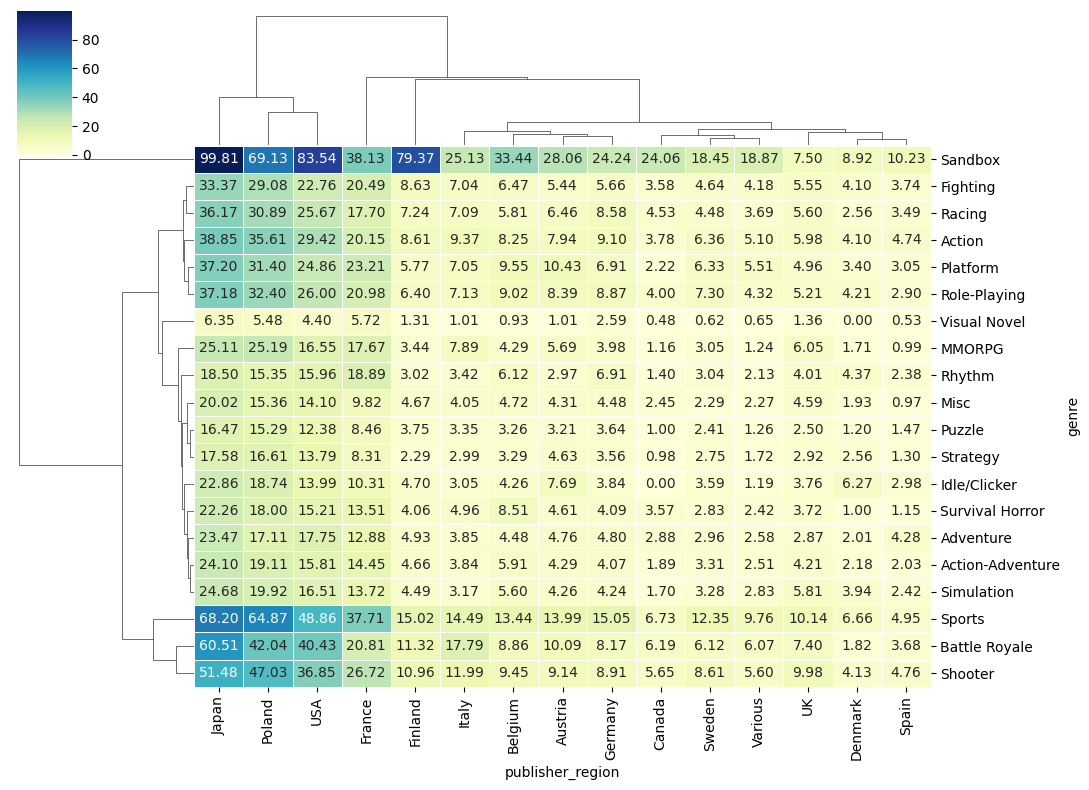

In [49]:

sns.clustermap(
    pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    figsize=(11,8)
)

**To understand the structure of the one-hot encoded platform features, the platform column was transformed into a binary matrix where each column represents a unique platform. The sparsity of this matrix was then calculated by measuring the proportion of zero values. A high sparsity percentage indicates that each game is typically released on only a few platforms relative to the total number of platforms in the dataset. This characteristic is common in one-hot encoded categorical data and has important implications for storage efficiency and machine learning algorithms.**

In [50]:
df_encoded = pd.get_dummies(df, columns=['platform'], dtype=int)

In [51]:

# 1. Isolate the platform columns AND force them to be strictly numeric
platform_cols = df_encoded.filter(like='platform_').select_dtypes(include=[np.number])

# 2. Count the total number of cells in these columns (rows × columns)
total_elements = platform_cols.size

# 3. Now summing will work flawlessly because it's purely numbers!
total_ones = platform_cols.sum().sum()

# 4. Calculate the zeros and the final sparsity percentage
total_zeros = total_elements - total_ones
sparsity_percentage = (total_zeros / total_elements) * 100

print(f"Total elements in platform matrix: {total_elements:,}")
print(f"Sparsity Percentage: {sparsity_percentage:.2f}%")

Total elements in platform matrix: 1,700,000
Sparsity Percentage: 84.13%


## How did the industry change over time?

> Year-over-year(YoY)

In [52]:
salesperyear = df.groupby("year")["global_sales_million"].sum()

yoy_growth = salesperyear.pct_change() * 100

yoy_report = pd.DataFrame({
    "Total_Sales_Millions": salesperyear,
    "YoY_Growth_Percent": yoy_growth
})


yoy_report.style\
    .background_gradient(cmap="RdYlGn", subset=["YoY_Growth_Percent"])\
    .format({
        "Total_Sales_Millions": "{:,.2f}",
        "YoY_Growth_Percent": "{:+.2f}%"
    })

,Total_Sales_Millions,YoY_Growth_Percent
year,,
1985,"18,106.27",+nan%
1986,"18,630.19",+2.89%
1987,"18,056.44",-3.08%
1988,"17,387.19",-3.71%
1989,"17,746.10",+2.06%
1990,"17,152.72",-3.34%
1991,"16,972.96",-1.05%
1992,"17,022.28",+0.29%
1993,"17,425.87",+2.37%


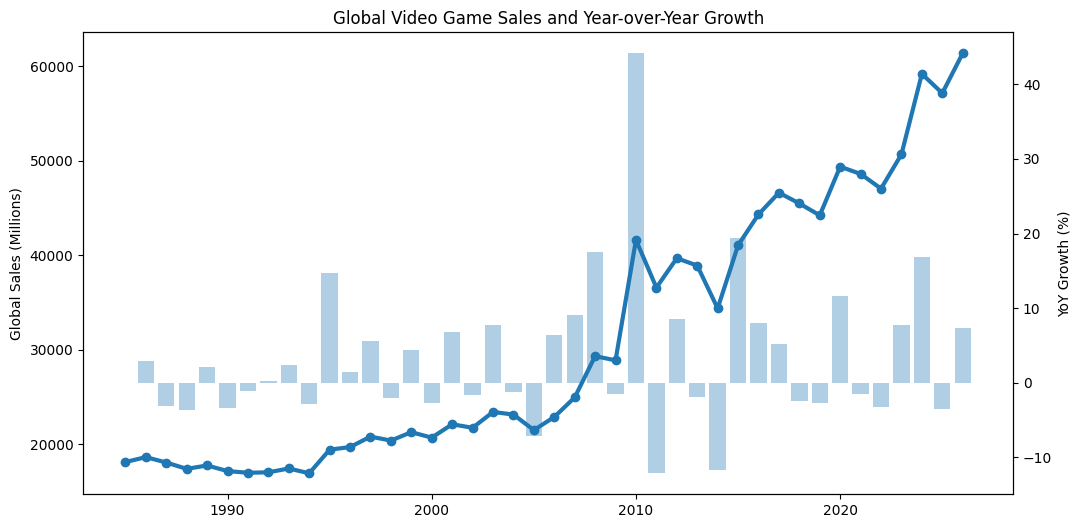

In [53]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Total Sales
ax1.plot(
    yoy_report.index,
    yoy_report["Total_Sales_Millions"],
    linewidth=3,
    marker="o",
    label="Total Sales"
)

ax1.set_ylabel("Global Sales (Millions)")

# Growth %
ax2 = ax1.twinx()

ax2.bar(
    yoy_report.index,
    yoy_report["YoY_Growth_Percent"],
    alpha=0.35,
    label="YoY Growth"
)

ax2.set_ylabel("YoY Growth (%)")

plt.title("Global Video Game Sales and Year-over-Year Growth")

plt.show()

**This analysis tracks the cumulative global sales of each game genre over time. Rather than examining annual sales alone, cumulative sales illustrate how each genre has contributed to the industry's overall growth throughout gaming history. Comparing these trends reveals which genres established long-term commercial dominance, which experienced rapid growth during particular periods, and which gradually lost momentum.**

In [70]:
newdf = df.sort_values('year').groupby('genre')['global_sales_million'].cumsum()


In [71]:
# 1. Sort the entire dataset chronologically first
df_sorted = df.sort_values(by="year").copy()

# 2. Calculate the cumulative total and assign it to a new column
df_sorted["cumulative_genre_sales"] = df_sorted.groupby("genre")["global_sales_million"].cumsum()

# 3. Keep a clean view of the tracking columns
genre_dominance = df_sorted[["year", "genre", "global_sales_million", "cumulative_genre_sales"]]

print(genre_dominance.tail(15))

       year          genre  global_sales_million  cumulative_genre_sales
22668  2026        Shooter             29.590000           169380.953125
3948   2026      Adventure             10.190000            39900.589844
37474  2026        Shooter            196.279999           169577.234375
25424  2026         Racing             10.420000            82745.328125
49927  2026         Sports             70.870003           263699.937500
15528  2026         Sports            138.880005           263838.843750
25382  2026       Fighting              6.490000            62515.570312
37505  2026         MMORPG              1.270000            16289.059570
15521  2026  Battle Royale            100.379997            37460.910156
49941  2026       Platform              6.740000            85004.796875
44352  2026         Action             37.040001           208197.937500
20039  2026       Strategy             22.530001            23439.390625
30583  2026         MMORPG              1.940000   

In [73]:
# Create a historical timeline matrix of genre dominance
timeline_matrix = df_sorted.pivot_table(
    index="year", 
    columns="genre", 
    values="cumulative_genre_sales", 
    aggfunc="max" # Takes the highest cumulative total reached in that year
).ffill()         # Forward-fills any years where a genre didn't release a game

print(timeline_matrix.tail())

genre         Action  Action-Adventure     Adventure  Battle Royale  \
year                                                                  
2022   175293.640625      26330.839844  32736.140625   30074.970703   
2023   182402.234375      27344.699219  34624.160156   31550.109375   
2024   190207.875000      28907.769531  36180.921875   34230.449219   
2025   198197.531250      30311.019531  38009.550781   36226.570312   
2026   208197.937500      31859.390625  39900.589844   37460.910156   

genre      Fighting  Idle/Clicker        MMORPG          Misc      Platform  \
year                                                                          
2022   49771.289062   4813.259766  14087.209961  21483.880859  70895.640625   
2023   52240.679688   5138.839844  14811.070312  22538.240234  74227.796875   
2024   54558.160156   5342.100098  15240.379883  23865.859375  78361.359375   
2025   57951.058594   5780.270020  15718.570312  24950.330078  81096.976562   
2026   62525.890625   6392.2

##  What was the most commercially successful three-year period in gaming history?

In [57]:
df['3years'] = df.groupby('year')['global_sales_million'].rolling(window=3).sum().reset_index(level=0, drop=True)


In [58]:
# 1. Aggregate total sales by year to get a clean chronological timeline
yearly_sales = df.groupby("year")["global_sales_million"].sum().sort_index()

# 2. Calculate the 3-year rolling sum across consecutive years
# (e.g., Year 2010 value will be the sum of 2008 + 2009 + 2010)
rolling_3yr = yearly_sales.rolling(window=3).sum()

# 3. Combine them into a clear evaluation DataFrame
peak_era_df = pd.DataFrame({
    "Yearly_Sales": yearly_sales,
    "3_Year_Rolling_Total": rolling_3yr
})

# 4. Find the absolute highest 3-year window in history
peak_era = peak_era_df.sort_values(by="3_Year_Rolling_Total", ascending=False).head(1)
print(peak_era)

      Yearly_Sales  3_Year_Rolling_Total
year                                    
2026      61368.56              177697.4


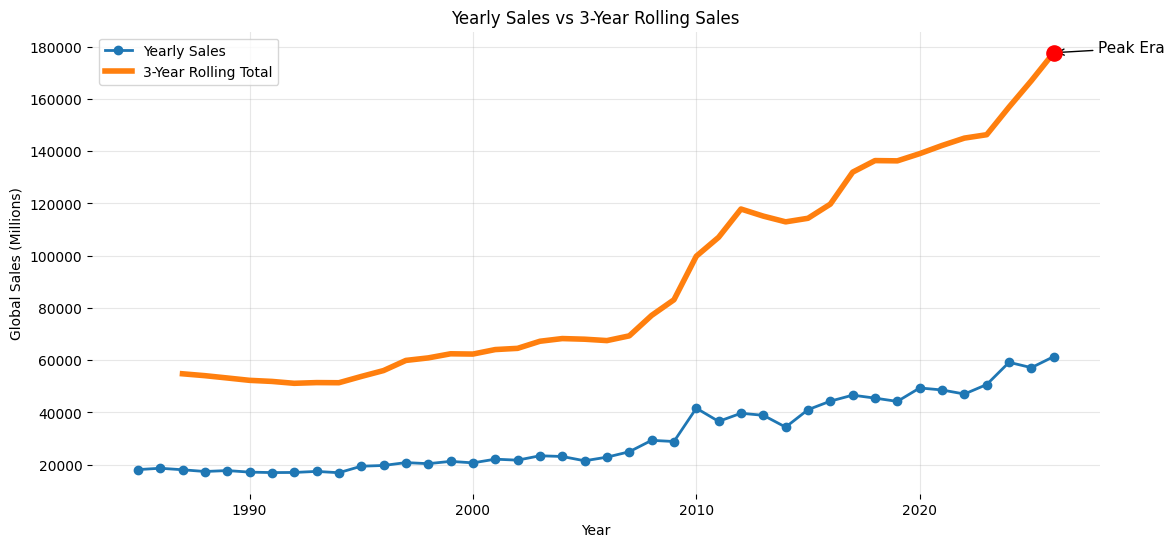

In [79]:
plt.figure(figsize=(13,6))

plt.plot(
    peak_era_df.index,
    peak_era_df["Yearly_Sales"],
    marker="o",
    linewidth=2,
    label="Yearly Sales"
)

plt.plot(
    peak_era_df.index,
    peak_era_df["3_Year_Rolling_Total"],
    linewidth=4,
    label="3-Year Rolling Total"
)

plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")

plt.title("Yearly Sales vs 3-Year Rolling Sales")

plt.legend()

plt.grid(alpha=.3)

peak_year = peak_era.index[0]

peak_value = peak_era["3_Year_Rolling_Total"].iloc[0]

plt.scatter(
    peak_year,
    peak_value,
    color="red",
    s=120,
    zorder=5
)

plt.annotate(
    "Peak Era",
    xy=(peak_year, peak_value),
    xytext=(peak_year+2, peak_value),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.show()

* Which genres contributed most to the peak era?

In [82]:
start = peak_year - 2
end = peak_year

peak_genres = (
    df[(df["year"] >= start) & (df["year"] <= end)]
    .groupby("genre")["global_sales_million"]
    .sum()
    .sort_values(ascending=False)
)
peak_genres

genre
Sports              36737.648438
Action              25795.689453
Shooter             23692.041016
Role-Playing        16433.939453
Platform            10777.000000
Fighting            10285.209961
Racing               9543.370117
Simulation           8031.870117
Battle Royale        5910.799805
Adventure            5276.430176
Sandbox              4625.419922
Action-Adventure     4514.689941
Puzzle               3749.429932
Misc                 3403.949951
Strategy             3190.929932
Survival Horror      1772.729980
MMORPG               1479.930054
Idle/Clicker         1253.459961
Rhythm                878.549988
Visual Novel          344.309998
Name: global_sales_million, dtype: float32

>  Massive Memory Optimization Audit
> Large datasets can slow down production servers. Let's optimize memory footprint.


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   game_id                             50000 non-null  object  
 1   title                               50000 non-null  object  
 2   platform                            50000 non-null  object  
 3   platform_type                       50000 non-null  object  
 4   platform_maker                      50000 non-null  object  
 5   platform_generation                 50000 non-null  int64   
 6   genre                               50000 non-null  object  
 7   year                                50000 non-null  int64   
 8   publisher                           50000 non-null  object  
 9   developer                           50000 non-null  object  
 10  publisher_region                    50000 non-null  object  
 11  publisher_tier              

In [60]:
float64_cols = list(df.select_dtypes(include='float64'))
df[float64_cols] = df[float64_cols].astype('float32')
df[["genre" , "platform"]] = df[["genre" , "platform"]].astype("category")

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   game_id                             50000 non-null  object  
 1   title                               50000 non-null  object  
 2   platform                            50000 non-null  category
 3   platform_type                       50000 non-null  object  
 4   platform_maker                      50000 non-null  object  
 5   platform_generation                 50000 non-null  int64   
 6   genre                               50000 non-null  category
 7   year                                50000 non-null  int64   
 8   publisher                           50000 non-null  object  
 9   developer                           50000 non-null  object  
 10  publisher_region                    50000 non-null  object  
 11  publisher_tier              

In [62]:
# 1. Check your new memory footprint
optimized_memory = df.memory_usage(deep=True).sum()

# 2. Print out the results (assuming you ran this check before downcasting too!)
# (If you didn't save the old footprint, you can read a fresh copy of the raw data to check)
raw_df = pd.read_csv("/kaggle/input/datasets/meruvakodandasuraj/video-game-sales-and-metacritic-intelligence-198026/games.csv") # Quick load to compare
original_memory = raw_df.memory_usage(deep=True).sum()

# 3. Calculate the percentage saved
bytes_saved = original_memory - optimized_memory
pct_saved = (bytes_saved / original_memory) * 100

print(f"Original Memory: {original_memory / (1024**2):.2f} MB")
print(f"Optimized Memory: {optimized_memory / (1024**2):.2f} MB")
print(f"Successfully slashed memory usage by {pct_saved:.2f}%!")

Original Memory: 38.97 MB
Optimized Memory: 32.68 MB
Successfully slashed memory usage by 16.15%!


## How long do publishers remain active after entering the industry?

In [63]:
df["cohort_year"] = df.groupby("publisher")["year"].transform("min")
df["years_since_debut"] = df["year"] - df["cohort_year"]

In [64]:
publisher_lifespans = df.groupby(["cohort_year", "publisher"])["years_since_debut"].max().reset_index()

publisher_lifespans["active_at_5_yrs"]  = publisher_lifespans["years_since_debut"] >= 5
publisher_lifespans["active_at_10_yrs"] = publisher_lifespans["years_since_debut"] >= 10
publisher_lifespans["active_at_15_yrs"] = publisher_lifespans["years_since_debut"] >= 15

cohort_matrix = publisher_lifespans.groupby("cohort_year").agg(
    total_started=('publisher', 'count'),
    survived_5_yrs=('active_at_5_yrs', 'sum'),
    survived_10_yrs=('active_at_10_yrs', 'sum'),
    survived_15_yrs=('active_at_15_yrs', 'sum')
)

print(cohort_matrix)

             total_started  survived_5_yrs  survived_10_yrs  survived_15_yrs
cohort_year                                                                 
1985                    24              24               24               24
1995                    27              27               27               27


* retention percentages.

In [83]:
cohort_matrix["5-Year Retention"] = (
    cohort_matrix["survived_5_yrs"] /
    cohort_matrix["total_started"] * 100
)

cohort_matrix["10-Year Retention"] = (
    cohort_matrix["survived_10_yrs"] /
    cohort_matrix["total_started"] * 100
)

cohort_matrix["15-Year Retention"] = (
    cohort_matrix["survived_15_yrs"] /
    cohort_matrix["total_started"] * 100
)

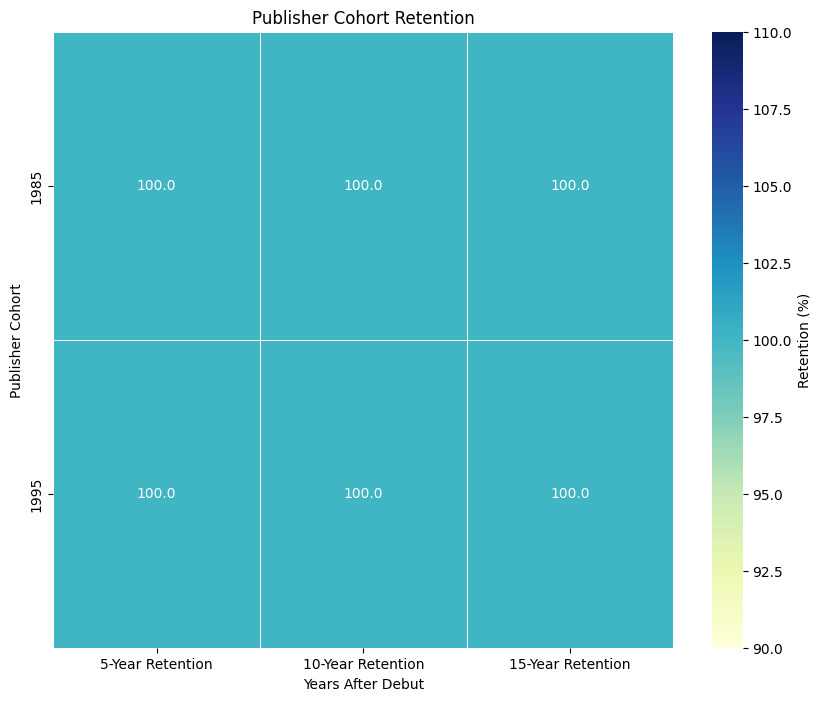

In [84]:
retention = cohort_matrix[
    ["5-Year Retention",
     "10-Year Retention",
     "15-Year Retention"]
]

plt.figure(figsize=(10,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={"label":"Retention (%)"}
)

plt.title("Publisher Cohort Retention")

plt.xlabel("Years After Debut")
plt.ylabel("Publisher Cohort")

plt.show()

In [85]:
publisher_lifetimes = (
    df.groupby("publisher")
      .agg(
          cohort_year=("year", "min"),
          last_year=("year", "max")
      )
)

publisher_lifetimes["lifetime"] = (
    publisher_lifetimes["last_year"] -
    publisher_lifetimes["cohort_year"]
)



max_lifetime = publisher_lifetimes["lifetime"].max()

years = range(max_lifetime + 1)

survival = []

for year in years:
    survival.append(
        (publisher_lifetimes["lifetime"] >= year).mean() * 100
    )







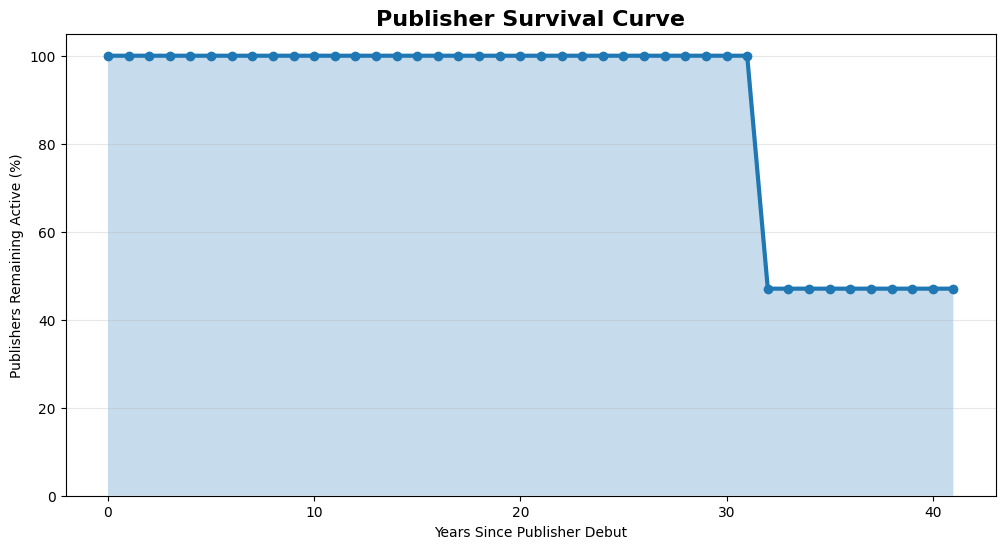

In [86]:

plt.figure(figsize=(12,6))

plt.plot(
    years,
    survival,
    linewidth=3,
    marker="o"
)

plt.fill_between(
    years,
    survival,
    alpha=0.25
)

plt.title(
    "Publisher Survival Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Years Since Publisher Debut")
plt.ylabel("Publishers Remaining Active (%)")

plt.ylim(0, 105)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Which genres does each publisher consistently excel at?

In [87]:
preference_matrix = df.pivot_table(
    index="publisher", 
    columns="genre", 
    values="metacritic_score", 
    aggfunc="mean"
)

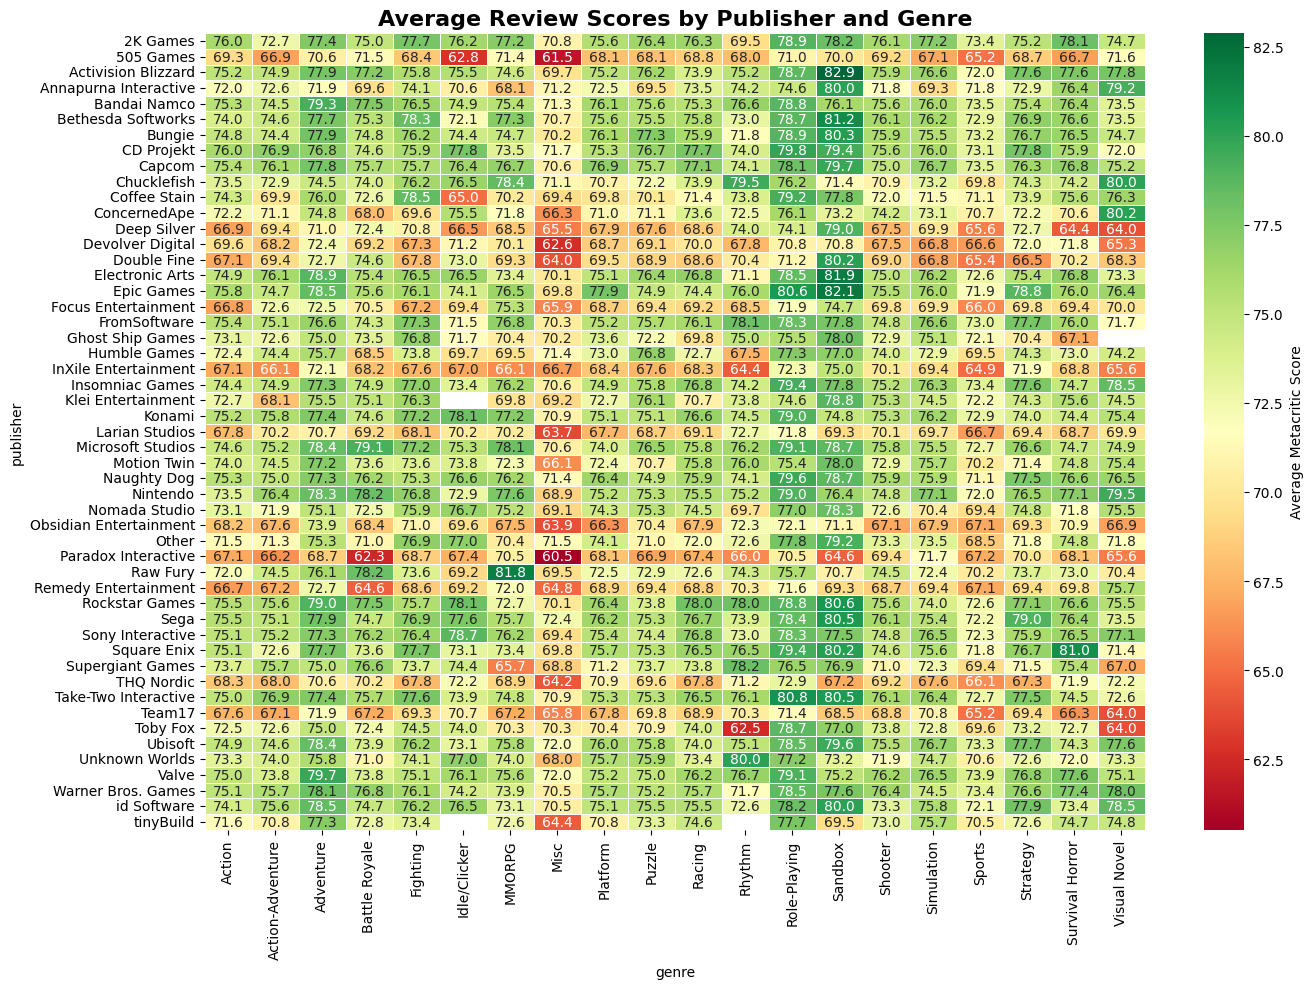

In [91]:

top_publishers = (
    df["publisher"]
      .value_counts()
      .loc[lambda x: x >= 10]
      .index
)

preference_matrix = (
    df[df["publisher"].isin(top_publishers)]
    .pivot_table(
        index="publisher",
        columns="genre",
        values="metacritic_score",
        aggfunc="mean"
    )
)

plt.figure(figsize=(14,10))

sns.heatmap(
    preference_matrix,
    cmap="RdYlGn",
    annot=True,
    fmt=".1f",
    linewidths=.5,
    cbar_kws={"label": "Average Metacritic Score"}
)

plt.title(
    "Average Review Scores by Publisher and Genre",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Which games exhibit unusual combinations of commercial success and critical reception?

In [92]:
features = ["global_sales_million", "metacritic_score"]
X = df[features].dropna()
iso_forest = IsolationForest(contamination=0.03, random_state=42)

X_predictions = iso_forest.fit_predict(X)

df["is_outlier"] = 1
df.loc[X.index, "is_outlier"] = X_predictions



In [93]:
outliers = df[df["is_outlier"] == -1]

In [94]:
print(f"Total Outliers Detected: {len(outliers)}")
print("\n---  TOP OUTLIER GAMES DETECTED  ---")
print(outliers[["title", "genre", "global_sales_million", "metacritic_score"]].head(10))

Total Outliers Detected: 1499

---  TOP OUTLIER GAMES DETECTED  ---
                      title          genre  global_sales_million  \
36        Shadow of Kingdom         Action            199.610001   
135  Counter-Strike Evolved        Shooter            297.720001   
141         Dragon Quest XI   Role-Playing             66.860001   
157      Forza Motorsport 5         Racing            515.359985   
184           PUBG: Eternal  Battle Royale            138.160004   
238        Firewatch Legacy      Adventure              0.720000   
372           Ridge Racer 3         Racing            216.300003   
377        Dragon Quest III   Role-Playing            197.470001   
404           PGA Tour 2025         Sports            187.130005   
414           Devil May Cry         Action           1407.660034   

     metacritic_score  
36                 72  
135                82  
141                99  
157                99  
184                88  
238                51  
372            